# Intelligent Music Recommendation Engine  

**Author:** Cédric Verhaegh  
**Student Number:** 221350  
**Project:** Intelligent Music Recommendation Engine (6 ECTS)  

**Module:** Applied Data Science & AI – Recommender Systems  
**Client:** (Simulated) Major Music Streaming Platform  
**Domain:** Recommender Systems / Media & Entertainment  
**Date:** June 2026 

---

# Table of Contents

This notebook is structured according to the four project phases from the project brief.

- [Phase 1 - Exploratory Data Analysis & Preprocessing](#Phase-1---Exploratory-Data-Analysis-&-Preprocessing)
  - [1.1 Load the data](#1.1-Load-the-data)
  - [1.2 Initial data-quality observations](#1.2-Initial-data-quality-observations)
  - [1.3 Distribution analysis: play counts](#1.3-Distribution-analysis:-play-counts)
  - [1.4 Distribution analysis: user activity and song popularity](#1.4-Distribution-analysis:-user-activity-and-song-popularity)
  - [1.5 Sparsity analysis](#1.5-Sparsity-analysis)
  - [1.6 Sparsity reduction experiments](#1.6-Sparsity-reduction-experiments)
  - [1.7 Outlier management and rating transformation](#1.7-Outlier-management-and-rating-transformation)
  - [1.8 Add readable song metadata](#1.8-Add-readable-song-metadata)
  - [1.9 Export Phase 1 outputs](#1.9-Export-Phase-1-outputs)
  - [1.10 Conclusion Phase 1](#1.10-Conclusion-Phase-1)
- [Phase 2 - Model Development](#Phase-2---Model-Development)
  - [2.1 Prepare the modelling data](#2.1-Prepare-the-modelling-data)
  - [2.2 Popularity-based baseline](#2.2-Popularity-based-baseline)
  - [2.3 Prepare Surprise data and helpers](#2.3-Prepare-Surprise-data-and-helpers)
  - [2.4 Item-item KNN collaborative filtering](#2.4-Item-item-KNN-collaborative-filtering)
  - [2.5 Matrix factorization with SVD](#2.5-Matrix-factorization-with-SVD)
  - [2.6 Co-Clustering](#2.6-Co-Clustering)
  - [2.7 Ensemble model](#2.7-Ensemble-model)
  - [2.8 Generate example Top 10 playlists](#2.8-Generate-example-Top-10-playlists)
  - [2.9 Conclusion Phase 2](#2.9-Conclusion-Phase-2)
- [Phase 3 - Evaluation & Metrics](#Phase-3---Evaluation-&-Metrics)
  - [3.1 Generate final test-set predictions](#3.1-Generate-final-test-set-predictions)
  - [3.2 Predictive accuracy: RMSE](#3.2-Predictive-accuracy:-RMSE)
  - [3.3 Ranking metrics: Precision@K, Recall@K, and F1@K](#3.3-Ranking-metrics:-Precision@K,-Recall@K,-and-F1@K)
  - [3.4 Classification metrics: ROC curves and AUC](#3.4-Classification-metrics:-ROC-curves-and-AUC)
  - [3.5 Combined evaluation summary](#3.5-Combined-evaluation-summary)
  - [3.6 Conclusion Phase 3](#3.6-Conclusion-Phase-3)
- [Phase 4 - Solution Design & Strategy](#Phase-4---Solution-Design-&-Strategy)
  - [4.1 Latency vs. accuracy](#4.1-Latency-vs.-accuracy)
  - [4.2 Deployment strategy](#4.2-Deployment-strategy)
  - [4.3 Cold-start strategy](#4.3-Cold-start-strategy)
  - [4.4 Conclusion Phase 4](#4.4-Conclusion-Phase-4)


---

# Phase 1 - Exploratory Data Analysis & Preprocessing

This section covers the first project phase from the brief: distribution analysis, sparsity reduction, and outlier management. The aim is not only to inspect the Million Song subset, but also to prepare a smaller, cleaner modelling dataset that can be used quickly for the baseline, KNN, SVD, Co-Clustering, and ensemble models.

The project data is implicit feedback: play counts rather than explicit star ratings. Because the classical `surprise` algorithms are designed for explicit user-item-rating triples, play counts will later be transformed into a bounded preference score. The raw `play_count` is still analysed first because the long-tail distribution and extreme values are important modelling risks.

In [1]:
# Core imports
from pathlib import Path
import warnings
import time

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

# Warnings and display settings
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 120)

# Random state for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [2]:
# Detect the project root robustly.
# When the notebook is opened from the notebooks folder, the project root is its parent folder.
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name.lower() == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

# Define the main project directories.
# The data folder stores raw CSV files, while figures and outputs store generated artefacts.
DATA_DIR = PROJECT_ROOT / "data"
FIGURES_DIR = PROJECT_ROOT / "figures"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
REPORTS_DIR = PROJECT_ROOT / "reports"

# Create output directories if they do not already exist.
# This prevents errors later when saving figures, tables, and report assets.
for folder in [FIGURES_DIR, OUTPUTS_DIR, REPORTS_DIR]:
    folder.mkdir(exist_ok=True)

# Define input file paths.
COUNT_DATA_PATH = DATA_DIR / "count_data.csv"
SONG_DATA_PATH = DATA_DIR / "song_data.csv"

# Verify that the notebook can find the required data files.
print("Project root:", PROJECT_ROOT)
print("Count data exists:", COUNT_DATA_PATH.exists())
print("Song data exists:", SONG_DATA_PATH.exists())

Project root: c:\Users\Cedri\OneDrive\Documents\GitHub\IntelligentMusicRecommendationEngine_CedricVerhaegh221350
Count data exists: True
Song data exists: True


## 1.1 Load the data

The interaction file contains the user-song-play-count data. The song metadata file contains descriptive song information. During inspection, the metadata CSV may contain malformed quoted text near the end of the file. For robustness, the metadata is loaded with Python's CSV engine and bad lines skipped. This is acceptable because the recommendation models are based on interaction data, while metadata is mainly used to make outputs readable.

In [3]:
# Load the user-song interaction data.
# This is the main modelling table because it contains user_id, song_id, and play_count.
interactions = pd.read_csv(COUNT_DATA_PATH)

# Drop the exported index column if it exists.
# This column does not carry modelling information.
if "Unnamed: 0" in interactions.columns:
    interactions = interactions.drop(columns=["Unnamed: 0"])

# Load song metadata.
# The Python engine with on_bad_lines="skip" makes loading more robust to malformed CSV rows.
# Metadata is mainly used to make recommendations readable, not as the primary modelling signal.
songs = pd.read_csv(SONG_DATA_PATH, engine="python", on_bad_lines="skip")

# Check whether both files loaded with the expected dimensions.
print("Interactions shape:", interactions.shape)
print("Songs metadata shape:", songs.shape)

# Inspect the first rows to verify that the columns match the project brief.
display(interactions.head())
display(songs.head())

Interactions shape: (2000000, 3)
Songs metadata shape: (1000000, 5)


,user_id,song_id,play_count
0,b80344d063b5ccb3212f76538f3d9e43d87dca9e,SOAKIMP12A8C130995,1
1,b80344d063b5ccb3212f76538f3d9e43d87dca9e,SOBBMDR12A8C13253B,2
2,b80344d063b5ccb3212f76538f3d9e43d87dca9e,SOBXHDL12A81C204C0,1
3,b80344d063b5ccb3212f76538f3d9e43d87dca9e,SOBYHAJ12A6701BF1D,1
4,b80344d063b5ccb3212f76538f3d9e43d87dca9e,SODACBL12A8C13C273,1


,song_id,title,release,artist_name,year
0,SOQMMHC12AB0180CB8,Silent Night,Monster Ballads X-Mas,Faster Pussy cat,2003
1,SOVFVAK12A8C1350D9,Tanssi vaan,Karkuteillä,Karkkiautomaatti,1995
2,SOGTUKN12AB017F4F1,No One Could Ever,Butter,Hudson Mohawke,2006
3,SOBNYVR12A8C13558C,Si Vos Querés,De Culo,Yerba Brava,2003
4,SOHSBXH12A8C13B0DF,Tangle Of Aspens,Rene Ablaze Presents Winter Sessions,Der Mystic,0


In [4]:
# Check data types and columns in user interactions
print("Interaction columns and dtypes:")
display(interactions.dtypes)

# Check data types and columns in song metadata
print("Song metadata columns and dtypes:")
display(songs.dtypes)

# Check for missing values in user interactions
print("Missing values in interactions:")
display(interactions.isna().sum())

# Check for missing values in song metadata
print("Missing values in song metadata:")
display(songs.isna().sum())

# Check for duplicates and unique counts in interactions and songs
print("Duplicate user-song interactions:", interactions.duplicated(subset=["user_id", "song_id"]).sum())
print("Unique users:", interactions["user_id"].nunique())
print("Unique songs in interactions:", interactions["song_id"].nunique())
print("Unique songs in metadata:", songs["song_id"].nunique())

# Check the overlap between interacted songs and metadata songs
print(
    "\nInteracted-song catalogue size relative to metadata catalogue:",
    round(interactions["song_id"].nunique() / songs["song_id"].nunique() * 100, 2),
    "%"
)

# Check how many interaction rows have a matching song_id in the metadata
metadata_coverage = interactions["song_id"].isin(songs["song_id"]).mean() * 100
print("Interaction rows with matching metadata:", round(metadata_coverage, 2), "%")

Interaction columns and dtypes:


user_id       object
song_id       object
play_count     int64
dtype: object

Song metadata columns and dtypes:


song_id        object
title          object
release        object
artist_name    object
year            int64
dtype: object

Missing values in interactions:


user_id       0
song_id       0
play_count    0
dtype: int64

Missing values in song metadata:


song_id         0
title          17
release         7
artist_name     0
year            0
dtype: int64

Duplicate user-song interactions: 0
Unique users: 76353
Unique songs in interactions: 10000
Unique songs in metadata: 999056

Interacted-song catalogue size relative to metadata catalogue: 1.0 %
Interaction rows with matching metadata: 100.0 %


## 1.2 Initial data-quality observations

The interaction dataset loaded successfully with 2,000,000 user-song interactions. It contains the three columns required for the recommender-system task: `user_id`, `song_id`, and `play_count`. There are no missing values in these columns, and there are no duplicate user-song interaction rows. This means the interaction table is already suitable as the main modelling table.

The song metadata dataset also loaded successfully and contains descriptive information such as `title`, `release`, `artist_name`, and `year`. A small number of missing values exists in the metadata fields, but this is not a major modelling issue because the main recommendation models in this project are collaborative-filtering models based on user-song interaction patterns. The metadata will mainly be used later to make recommendation outputs readable, for example by showing song titles and artist names instead of only `song_id` values.

The interaction data contains 76,353 unique users and 10,000 unique songs. This means the natural representation of the problem is a user-song matrix with users as rows, songs as columns, and play counts as observed feedback values. Since only 2,000,000 user-song pairs are observed out of all possible user-song combinations, the matrix is expected to be highly sparse.

A key modelling point is that missing user-song pairs should not automatically be interpreted as dislikes. In recommender-system data, a missing interaction often means that the user has not been exposed to the song, not that they actively disliked it. This distinction is especially important for implicit feedback data such as play counts. A play count indicates that a user listened to a song, but the absence of a play count is mostly unknown preference information.

This also explains the later evaluation strategy. Instead of treating every unobserved song as a negative example, the offline evaluation will hide a subset of known interactions and test whether the models can recover or rank those interactions highly. This matches the idea from recommender-system evaluation literature that offline experiments simulate future recommendation behaviour by hiding known historical interactions and comparing model predictions against them.

## 1.3 Distribution analysis: play counts

The brief explicitly mentions a long-tail / power-law distribution. I therefore inspect play counts directly and with log-scaled plots. This matters because a small number of very high play counts can dominate a model if raw counts are used as ratings.

count    2.000000e+06
mean     3.045485e+00
std      6.579720e+00
min      1.000000e+00
50%      1.000000e+00
75%      3.000000e+00
90%      6.000000e+00
95%      1.000000e+01
99%      2.600000e+01
99.5%    3.600000e+01
99.9%    7.200000e+01
max      2.213000e+03
Name: play_count, dtype: float64

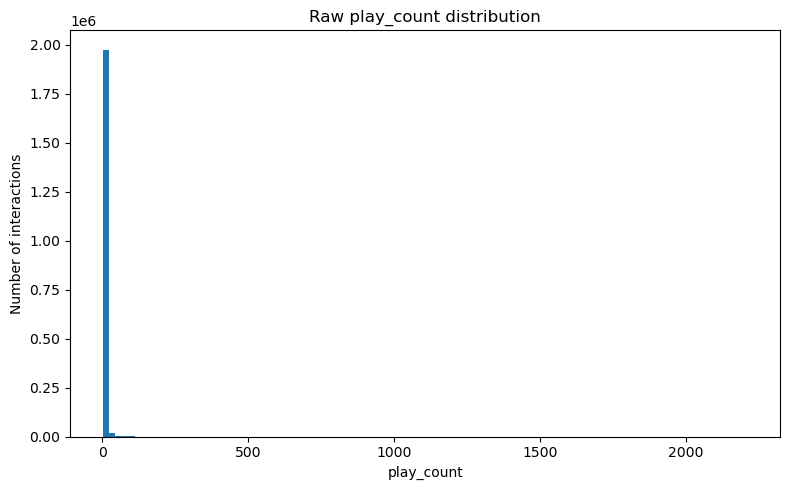

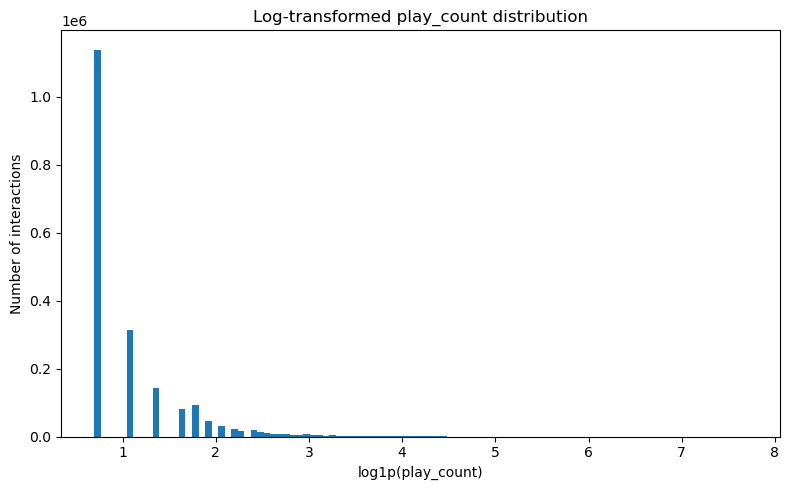

In [5]:
# Summarize raw play counts with high percentiles.
# High percentiles are useful here because the distribution is expected to have extreme values.
play_count_summary = interactions["play_count"].describe(
    percentiles=[0.50, 0.75, 0.90, 0.95, 0.99, 0.995, 0.999]
)
display(play_count_summary)

# Plot the raw play-count distribution.
# The raw plot shows how strongly a few extreme values stretch the x-axis.
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(interactions["play_count"], bins=100)
ax.set_title("Raw play_count distribution")
ax.set_xlabel("play_count")
ax.set_ylabel("Number of interactions")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "phase1_raw_play_count_distribution.png", dpi=150)
plt.show()

# Plot a log-transformed version of play_count.
# log1p compresses large values while preserving order, making the long tail easier to inspect.
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(np.log1p(interactions["play_count"]), bins=100)
ax.set_title("Log-transformed play_count distribution")
ax.set_xlabel("log1p(play_count)")
ax.set_ylabel("Number of interactions")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "phase1_log_play_count_distribution.png", dpi=150)
plt.show()

### Observation for report

The play-count distribution is extremely right-skewed. The median play count is only 1, and 75% of all user-song interactions have a play count of 3 or lower. Even at the 99.9th percentile, the play count is 72, while the maximum value is 2213. This shows that only a very small number of interactions have extremely high play counts.

The raw histogram confirms this visually: almost all interactions are compressed into the far-left side of the plot, while the x-axis is stretched by a few extreme values. The log-transformed histogram makes the distribution easier to interpret because `log1p(play_count)` compresses the long tail while preserving the ordering of play counts.

This matters for modelling because the data contains implicit feedback rather than explicit ratings. A higher play count can indicate stronger preference, but it can also be caused by playlist repetition, habit, background listening, or unusual user behaviour. Therefore, raw play counts should not be used directly as rating values. Before using Surprise models, the play counts should be clipped and log-transformed into a bounded rating-like score. This reduces the influence of extreme values and makes the data more suitable for RMSE-based model training and evaluation.

## 1.4 Distribution analysis: user activity and song popularity

Next, I aggregate interactions per user and per song. This identifies two recommender-system issues:

1. Very inactive users provide little information for collaborative filtering.
2. Very popular songs can dominate recommendations and create popularity bias.

In [6]:
# Aggregate interactions at user level.
# n_songs measures how much listening history each user provides for collaborative filtering.
# total_plays and avg_play_count describe overall engagement intensity.
user_activity = (
    interactions.groupby("user_id")
    .agg(
        n_songs=("song_id", "nunique"),
        total_plays=("play_count", "sum"),
        avg_play_count=("play_count", "mean")
    )
    .reset_index()
)

# Aggregate interactions at song level.
# n_users measures how broadly each song is listened to across the user base.
# This is useful for identifying popularity bias and long-tail behaviour.
song_popularity = (
    interactions.groupby("song_id")
    .agg(
        n_users=("user_id", "nunique"),
        total_plays=("play_count", "sum"),
        avg_play_count=("play_count", "mean")
    )
    .reset_index()
)

# Summarize user activity.
# Very inactive users may be difficult to model because collaborative filtering needs enough history.
print("User activity summary: number of unique songs per user")
display(user_activity["n_songs"].describe(percentiles=[0.50, 0.75, 0.90, 0.95, 0.99, 0.995, 0.999]))

# Summarize song popularity.
# Very rare songs increase sparsity, while very popular songs can dominate recommendation results.
print("Song popularity summary: number of unique listeners per song")
display(song_popularity["n_users"].describe(percentiles=[0.50, 0.75, 0.90, 0.95, 0.99, 0.995, 0.999]))

User activity summary: number of unique songs per user


count    76353.000000
mean        26.194125
std         31.625078
min          1.000000
50%         16.000000
75%         31.000000
90%         58.000000
95%         82.000000
99%        157.480000
99.5%      196.000000
99.9%      295.648000
max        711.000000
Name: n_songs, dtype: float64

Song popularity summary: number of unique listeners per song


count    10000.000000
mean       200.000000
std        317.715673
min         48.000000
50%        124.000000
75%        201.000000
90%        344.000000
95%        491.000000
99%       1496.040000
99.5%     2076.185000
99.9%     3976.572000
max       8277.000000
Name: n_users, dtype: float64

In [7]:
# Summarize total play counts at user and song level.
# This shows whether total listening volume is concentrated among a small group of users or songs.
print("User total play-count summary:")
display(
    user_activity["total_plays"].describe(
        percentiles=[0.50, 0.75, 0.90, 0.95, 0.99, 0.995, 0.999]
    )
)

print("Song total play-count summary:")
display(
    song_popularity["total_plays"].describe(
        percentiles=[0.50, 0.75, 0.90, 0.95, 0.99, 0.995, 0.999]
    )
)

User total play-count summary:


count    76353.000000
mean        79.773801
std        116.299183
min          1.000000
50%         41.000000
75%         95.000000
90%        194.000000
95%        283.000000
99%        551.000000
99.5%      689.000000
99.9%     1070.296000
max       4426.000000
Name: total_plays, dtype: float64

Song total play-count summary:


count    10000.000000
mean       609.096900
std       1401.268442
min         71.000000
50%        336.000000
75%        587.000000
90%       1081.100000
95%       1666.200000
99%       5067.080000
99.5%     7361.330000
99.9%    18054.255000
max      54136.000000
Name: total_plays, dtype: float64

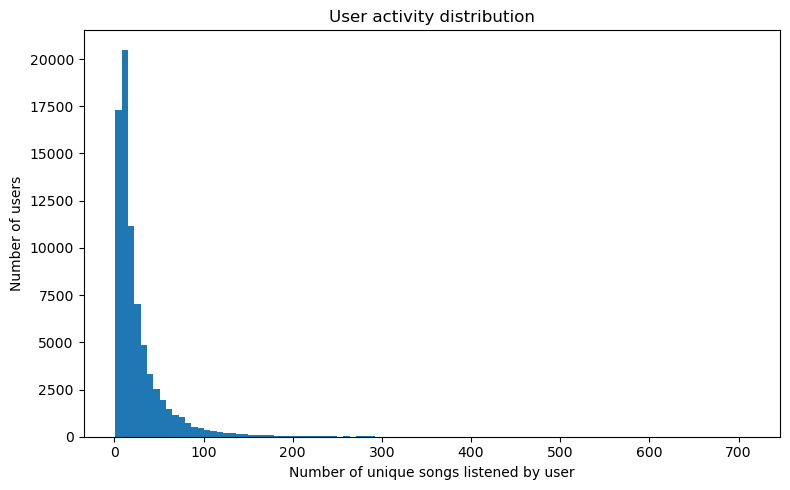

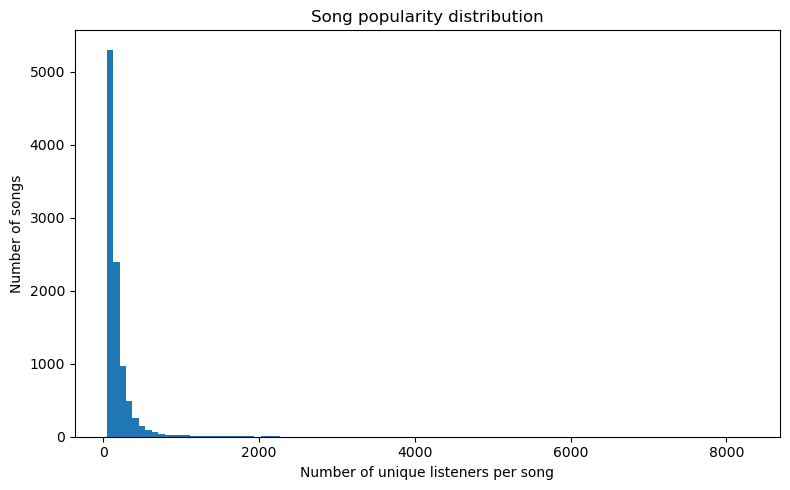

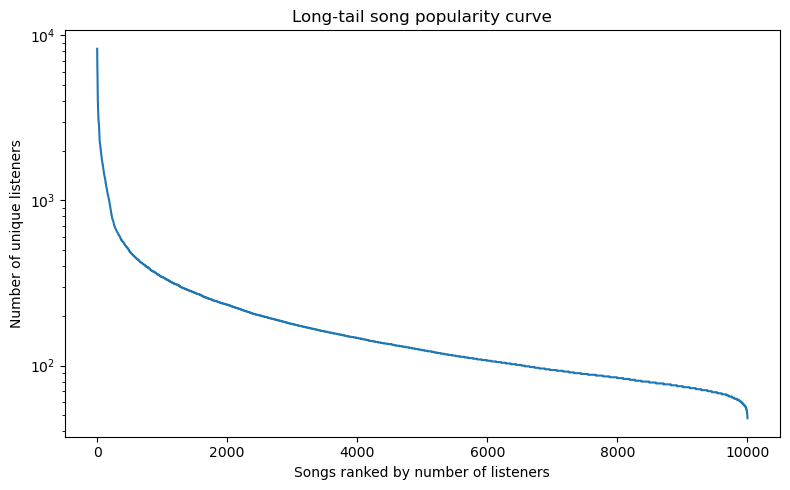

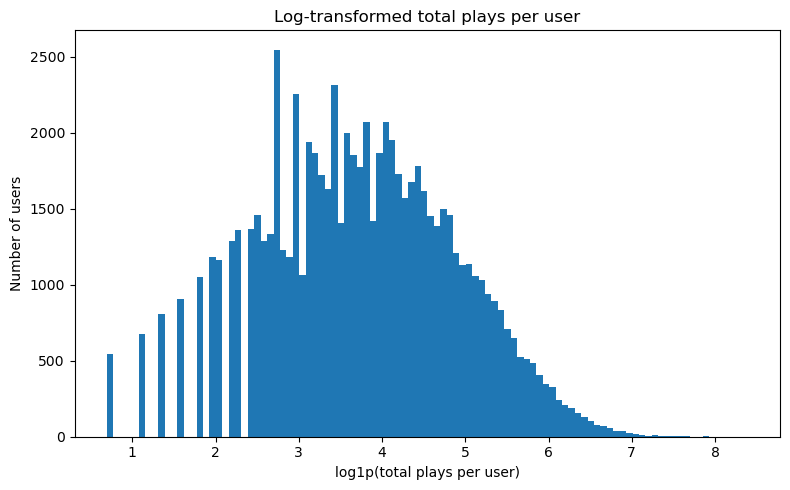

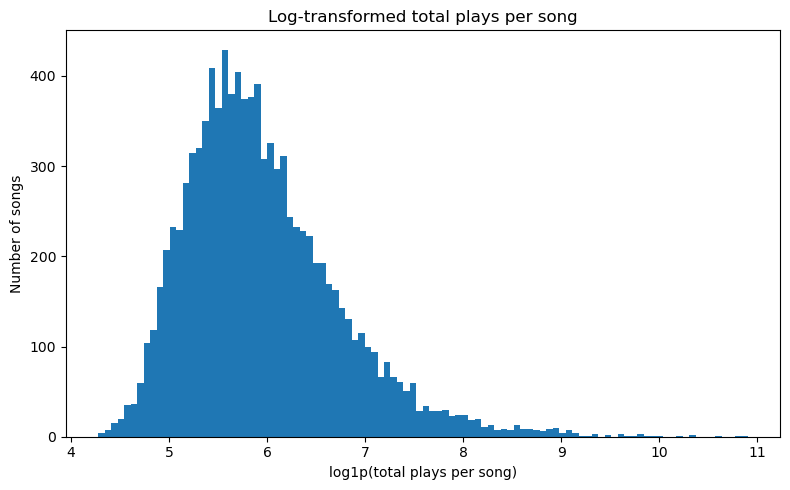

In [8]:
# Plot how many unique songs users listened to.
# The expected skew helps decide whether low-activity users should be filtered before modelling.
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(user_activity["n_songs"], bins=100)
ax.set_title("User activity distribution")
ax.set_xlabel("Number of unique songs listened by user")
ax.set_ylabel("Number of users")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "phase1_user_activity_distribution.png", dpi=150)
plt.show()

# Plot how many unique listeners each song has.
# This shows whether the catalogue is dominated by a small number of highly popular songs.
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(song_popularity["n_users"], bins=100)
ax.set_title("Song popularity distribution")
ax.set_xlabel("Number of unique listeners per song")
ax.set_ylabel("Number of songs")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "phase1_song_popularity_distribution.png", dpi=150)
plt.show()

# Plot songs ranked by popularity.
# The log-scaled y-axis makes the long-tail pattern easier to see.
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(
    np.arange(1, len(song_popularity) + 1),
    song_popularity.sort_values("n_users", ascending=False)["n_users"].values
)
ax.set_title("Long-tail song popularity curve")
ax.set_xlabel("Songs ranked by number of listeners")
ax.set_ylabel("Number of unique listeners")
ax.set_yscale("log")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "phase1_long_tail_song_popularity.png", dpi=150)
plt.show()

# Plot total plays per user on a log scale.
# This shows whether listening volume is concentrated among a small number of highly active users.
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(np.log1p(user_activity["total_plays"]), bins=100)
ax.set_title("Log-transformed total plays per user")
ax.set_xlabel("log1p(total plays per user)")
ax.set_ylabel("Number of users")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "phase1_log_total_plays_per_user.png", dpi=150)
plt.show()

# Plot total plays per song on a log scale.
# This shows whether total listening volume is concentrated among a small number of songs.
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(np.log1p(song_popularity["total_plays"]), bins=100)
ax.set_title("Log-transformed total plays per song")
ax.set_xlabel("log1p(total plays per song)")
ax.set_ylabel("Number of songs")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "phase1_log_total_plays_per_song.png", dpi=150)
plt.show()

### Observation for report

The user activity distribution shows that most users have relatively limited listening histories. The median user listened to 16 unique songs, and 75% of users listened to 31 or fewer unique songs. However, a small number of users listened to hundreds of songs, with the maximum user having 711 unique songs. This confirms that user activity is uneven, which matters because collaborative filtering depends on overlap between users or items. Users with very little history provide limited information for personalization.

The song popularity distribution also shows a strong long-tail pattern. The median song has 124 unique listeners, while the most popular song has 8277 unique listeners. The long-tail curve makes this clearer: a small number of songs attract many listeners, while most songs are listened to by far fewer users.

This creates an important modelling trade-off. Popular songs provide strong and reliable signals, so a popularity-based recommender is useful as a baseline and as a cold-start fallback. However, relying too much on popularity can create popularity bias, where the system repeatedly recommends mainstream songs and gives less exposure to niche or long-tail songs. For the later models, this supports using collaborative filtering and matrix factorization to personalize beyond simple popularity, while still keeping popularity as a meaningful benchmark.

The total-play summaries confirm that listening volume is also uneven at both user and song level. Some users contribute many more plays than others, and some songs receive far more total plays than the rest of the catalogue. This reinforces the earlier long-tail finding: without preprocessing, models may overfit to highly active users or highly popular songs. This supports the later choice to use filtering, clipping, and log transformation before training recommender models.

## 1.5 Sparsity analysis

Collaborative filtering works on a user-item matrix. In this project, users form the rows, songs form the columns, and observed play counts form the known entries. The matrix is sparse because each user listens to only a small fraction of all available songs.

Sparsity is calculated as:

$$
\text{Sparsity} = 1 - \frac{\text{observed user-song interactions}}{\text{unique users} \times \text{unique songs}}
$$

A sparsity value close to 1 means that most user-song pairs are missing. This does not mean that users dislike those songs. It mostly means that their preference is unknown.


In [9]:
def calculate_sparsity(df, user_col="user_id", item_col="song_id"):
    """
    Calculate the sparsity and density of a user-item interaction matrix.

    Sparsity measures the proportion of missing user-item pairs.
    Density measures the proportion of observed user-item pairs.

    In this project, a high sparsity value is expected because each user only
    listens to a small subset of the full song catalogue.
    """
    # Count the number of unique users and songs represented in the dataframe.
    n_users = df[user_col].nunique()
    n_items = df[item_col].nunique()

    # Each row represents one observed user-song interaction.
    n_observed = len(df)

    # This is the full matrix size if every user had interacted with every song.
    total_possible = n_users * n_items

    # Density is the observed fraction of the user-song matrix.
    density = n_observed / total_possible if total_possible > 0 else 0

    # Sparsity is the missing fraction of the user-song matrix.
    sparsity = 1 - density

    return {
        "n_users": n_users,
        "n_items": n_items,
        "n_observed": n_observed,
        "total_possible": total_possible,
        "sparsity": sparsity,
        "density": density,
        "sparsity_%": sparsity * 100,
        "density_%": density * 100,
    }

In [10]:
# Calculate sparsity for the raw interaction table.
# This gives the baseline sparsity before any filtering is applied.
raw_sparsity = calculate_sparsity(interactions)
raw_sparsity_df = pd.DataFrame([raw_sparsity])

display(raw_sparsity_df)

,n_users,n_items,n_observed,total_possible,sparsity,density,sparsity_%,density_%
0,76353,10000,2000000,763530000,0.997381,0.002619,99.738059,0.261941


### Observation for report

The raw user-song matrix is extremely sparse. The dataset contains 76,353 users and 10,000 songs, which means there are 763,530,000 possible user-song combinations. Only 2,000,000 of those combinations are observed, resulting in a density of about 0.26% and a sparsity of about 99.74%.

This confirms that the recommendation problem cannot be treated as a complete table of preferences. Most missing user-song pairs are unknown, not negative. This is important for collaborative filtering because models such as KNN, SVD, and Co-Clustering must infer preferences from a very small number of observed interactions.

## 1.6 Sparsity reduction experiments

The project brief asks for filtering techniques to reduce sparsity, such as removing users who listened to fewer than `N` songs and songs with fewer than `M` unique listeners. This section tests several threshold combinations before choosing a pragmatic preprocessing strategy.

The goal is not to make the matrix dense, because recommender-system matrices are naturally sparse. Instead, the goal is to remove users and songs with too little collaborative signal while keeping enough data to train and compare multiple models.

Important methodological note: filtering improves computational feasibility, but it also introduces bias. Removing low-activity users and rare songs makes the dataset easier to model, but it also makes the remaining dataset less representative of new, casual, or niche-listening users. This limitation should be mentioned in the technical report.

In [11]:
def filter_by_activity(df, min_songs_per_user=20, min_users_per_song=50, max_iterations=10):
    """
    Iteratively filter users and songs with too little collaborative signal.

    The filtering is iterative because removing inactive users can reduce the
    listener count of songs, and removing rare songs can reduce the activity
    count of users. The loop stops when no more rows are removed.
    """
    filtered = df.copy()

    for iteration in range(max_iterations):
        before_rows = len(filtered)

        # Keep users with at least the required number of unique listened songs.
        # Users below this threshold provide limited history for personalization.
        user_counts = filtered.groupby("user_id")["song_id"].nunique()
        keep_users = user_counts[user_counts >= min_songs_per_user].index
        filtered = filtered[filtered["user_id"].isin(keep_users)]

        # Keep songs with at least the required number of unique listeners.
        # Songs below this threshold have limited collaborative signal.
        song_counts = filtered.groupby("song_id")["user_id"].nunique()
        keep_songs = song_counts[song_counts >= min_users_per_song].index
        filtered = filtered[filtered["song_id"].isin(keep_songs)]

        after_rows = len(filtered)

        # Stop when the filtering step no longer changes the dataset.
        if after_rows == before_rows:
            break

    return filtered

In [12]:
# Compare several filtering thresholds before choosing the final preprocessing strategy.
# The goal is to reduce sparsity and computation time without removing too much useful data.
threshold_results = []

for min_user_songs in [5, 10, 20, 30]:
    for min_song_users in [10, 20, 30, 50]:
        # Apply one threshold combination.
        temp = filter_by_activity(
            interactions,
            min_songs_per_user=min_user_songs,
            min_users_per_song=min_song_users,
        )

        # Calculate the resulting matrix size and sparsity.
        sparse = calculate_sparsity(temp)

        threshold_results.append({
            "min_songs_per_user": min_user_songs,
            "min_users_per_song": min_song_users,
            "rows": len(temp),
            "users": sparse["n_users"],
            "songs": sparse["n_items"],
            "sparsity": sparse["sparsity"],
            "density": sparse["density"],
            "sparsity_%": sparse["sparsity_%"],
            "density_%": sparse["density_%"],
        })

threshold_results_df = pd.DataFrame(threshold_results)

# Sort results so the effect of increasing thresholds is easy to inspect.
threshold_results_df = threshold_results_df.sort_values(
    ["min_songs_per_user", "min_users_per_song"]
).reset_index(drop=True)

# Display the threshold comparison with selected columns and rounded values for better readability.
display(
    threshold_results_df[
        ["min_songs_per_user", "min_users_per_song", "rows", "users", "songs", "sparsity_%", "density_%"]
    ].round(3)
)

# Save the threshold comparison for later use in the technical report.
threshold_results_df.to_csv(
    OUTPUTS_DIR / "phase1_filtering_threshold_comparison.csv",
    index=False
)

,min_songs_per_user,min_users_per_song,rows,users,songs,sparsity_%,density_%
0,5,10,1984110,70715,10000,99.719,0.281
1,5,20,1984110,70715,10000,99.719,0.281
2,5,30,1984110,70715,10000,99.719,0.281
3,5,50,1983960,70713,9997,99.719,0.281
4,10,10,1875686,55618,10000,99.663,0.337
5,10,20,1875686,55618,10000,99.663,0.337
6,10,30,1875686,55618,10000,99.663,0.337
7,10,50,1873667,55569,9966,99.662,0.338
8,20,10,1543066,31424,10000,99.509,0.491
9,20,20,1543066,31424,10000,99.509,0.491


### Chosen preprocessing strategy

Based on the threshold comparison, I use a moderate full-data filtering strategy of at least 20 unique songs per user and at least 50 unique listeners per song. This keeps a large amount of data while removing the sparsest users and songs.

For model comparison, I also create a smaller reproducible modelling sample. This is necessary because memory-based KNN and Co-Clustering can become computationally expensive on the full 2-million-row dataset. The modelling sample is created by sampling users rather than individual interaction rows, because user-level sampling better preserves realistic user histories.

In [13]:
# Full cleaned dataset for EDA-level reporting and possible final training.
# These thresholds remove the sparsest users and songs while keeping most of the catalogue.
MIN_SONGS_PER_USER_FULL = 20
MIN_USERS_PER_SONG_FULL = 50

filtered_full = filter_by_activity(
    interactions,
    min_songs_per_user=MIN_SONGS_PER_USER_FULL,
    min_users_per_song=MIN_USERS_PER_SONG_FULL,
)

print("Filtered full shape:", filtered_full.shape)

# Display sparsity after full-data filtering.
# This allows direct comparison with the raw matrix sparsity from section 1.5.
filtered_full_sparsity = pd.DataFrame([calculate_sparsity(filtered_full)])
display(filtered_full_sparsity)

Filtered full shape: (1504680, 3)


,n_users,n_items,n_observed,total_possible,sparsity,density,sparsity_%,density_%
0,30800,9399,1504680,289489200,0.994802,0.005198,99.480229,0.519771


In [14]:
# Reproducible modelling sample for faster model training and comparison.
# Sampling users instead of rows preserves complete listening histories for sampled users.
MODEL_N_USERS = 3000
MODEL_MIN_SONGS_PER_USER = 20
MODEL_MIN_USERS_PER_SONG = 10

# First select users with enough listening history to support collaborative filtering.
eligible_users = (
    interactions.groupby("user_id")["song_id"]
    .nunique()
    .loc[lambda s: s >= MODEL_MIN_SONGS_PER_USER]
    .index
)

# Sample users reproducibly using the global random state.
rng = np.random.default_rng(RANDOM_STATE)
sampled_users = rng.choice(
    eligible_users,
    size=min(MODEL_N_USERS, len(eligible_users)),
    replace=False
)

# Keep all interactions from the sampled users.
# This avoids breaking user histories in the way that row-level random sampling would.
model_interactions = interactions[
    interactions["user_id"].isin(sampled_users)
].copy()

# Remove songs that are too rare within the sampled subset.
# This improves overlap between users and makes KNN/Co-Clustering more feasible.
song_counts_in_sample = model_interactions.groupby("song_id")["user_id"].nunique()
keep_sample_songs = song_counts_in_sample[
    song_counts_in_sample >= MODEL_MIN_USERS_PER_SONG
].index

model_interactions = model_interactions[
    model_interactions["song_id"].isin(keep_sample_songs)
].copy()

# Re-apply iterative filtering because removing rare songs can make some users too sparse.
model_interactions = filter_by_activity(
    model_interactions,
    min_songs_per_user=MODEL_MIN_SONGS_PER_USER,
    min_users_per_song=MODEL_MIN_USERS_PER_SONG,
)

print("Model interactions shape:", model_interactions.shape)

# Display sparsity for the modelling sample.
# This sample is still sparse, but it is small enough for fast model comparison.
model_sparsity = pd.DataFrame([calculate_sparsity(model_interactions)])
display(model_sparsity)

Model interactions shape: (97215, 3)


,n_users,n_items,n_observed,total_possible,sparsity,density,sparsity_%,density_%
0,2174,4128,97215,8974272,0.989167,0.010833,98.916737,1.083263


### Observation for report

The filtering experiments show that the dataset remains sparse under all tested thresholds, which is expected for recommender-system data. The raw matrix has a density of only about 0.26%. After applying the chosen full-data filtering strategy, the density increases to about 0.52%. This is an improvement, but the matrix is still more than 99% sparse.

The chosen full filtering strategy keeps 1,504,680 interactions, 30,800 users, and 9,399 songs. This is a reasonable compromise: it removes users and songs with very weak collaborative signal while preserving a large part of the dataset.

For model comparison, a smaller user-sampled dataset is used. This sample contains 97,215 interactions, 2,174 users, and 4,128 songs. It remains sparse, with a density of about 1.08%, but it is small enough to train and compare KNN, SVD, Co-Clustering, and ensemble approaches efficiently. Sampling users instead of random rows is important because it preserves complete user listening histories within the sample.

## 1.7 Outlier management and rating transformation

The raw data contains implicit feedback: play counts. However, the next phase will use classical algorithms that expect numeric rating-like values. I therefore do three things:

1. Clip extreme play counts at a high percentile.
2. Apply `log1p(play_count)` so the jump from 1 to 5 plays matters more than the jump from 100 to 104 plays.
3. Scale the transformed value into a bounded 1-5 preference score.

This keeps the signal that repeated listening indicates stronger preference, while reducing the impact of extreme outliers.

In [15]:
# Define the clipping threshold for extreme play counts.
# The 99th percentile keeps almost all normal listening behaviour while limiting extreme outliers.
OUTLIER_CLIP_QUANTILE = 0.99
clip_value = model_interactions["play_count"].quantile(OUTLIER_CLIP_QUANTILE)

# Clip extreme play counts.
# This prevents a very small number of unusually high play counts from dominating the rating scale.
model_interactions["play_count_clipped"] = model_interactions["play_count"].clip(
    upper=clip_value
)

# Apply a log transformation to compress the long tail.
# log1p is used because it works safely with low counts and preserves the ordering of play counts.
model_interactions["play_count_log"] = np.log1p(
    model_interactions["play_count_clipped"]
)

# Scale the log-transformed play counts to a 1-5 rating-like preference score.
# In this project, rating=1 means the weakest observed listening signal, not an explicit dislike.
min_log = model_interactions["play_count_log"].min()
max_log = model_interactions["play_count_log"].max()

model_interactions["rating"] = 1 + 4 * (
    (model_interactions["play_count_log"] - min_log) / (max_log - min_log)
)

# Create a binary repeated-listen label for later ROC/AUC evaluation.
# A song is labelled as liked when the user listened to it at least twice.
model_interactions["liked"] = (
    model_interactions["play_count"] >= 2
).astype(int)

print("Clip value at", OUTLIER_CLIP_QUANTILE, "quantile:", clip_value)

display(
    model_interactions[
        ["play_count", "play_count_clipped", "play_count_log", "rating", "liked"]
    ].describe()
)

Clip value at 0.99 quantile: 25.0


,play_count,play_count_clipped,play_count_log,rating,liked
count,97215.000000,97215.000000,97215.000000,97215.000000,97215.000000
mean,2.993427,2.807972,1.091710,1.621553,0.432053
std,5.854862,3.900884,0.595680,0.928954,0.495364
min,1.000000,1.000000,0.693147,1.000000,0.000000
25%,1.000000,1.000000,0.693147,1.000000,0.000000
50%,1.000000,1.000000,0.693147,1.000000,0.000000
75%,3.000000,3.000000,1.386294,2.080953,1.000000
max,319.000000,25.000000,3.258097,5.000000,1.000000


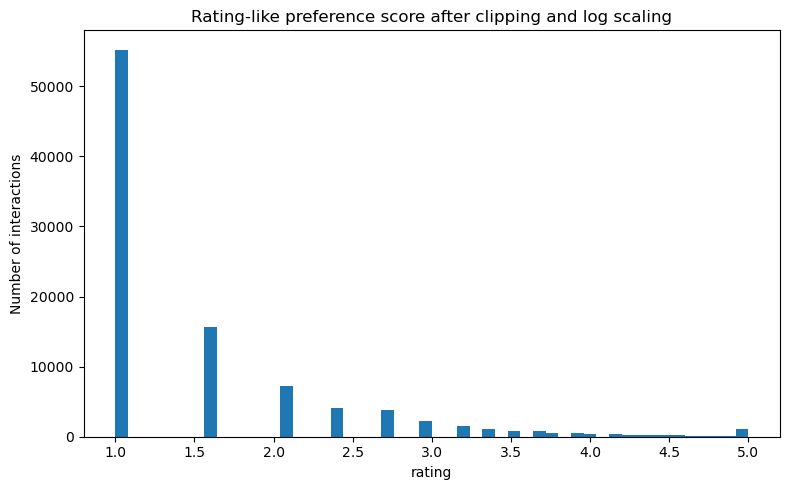

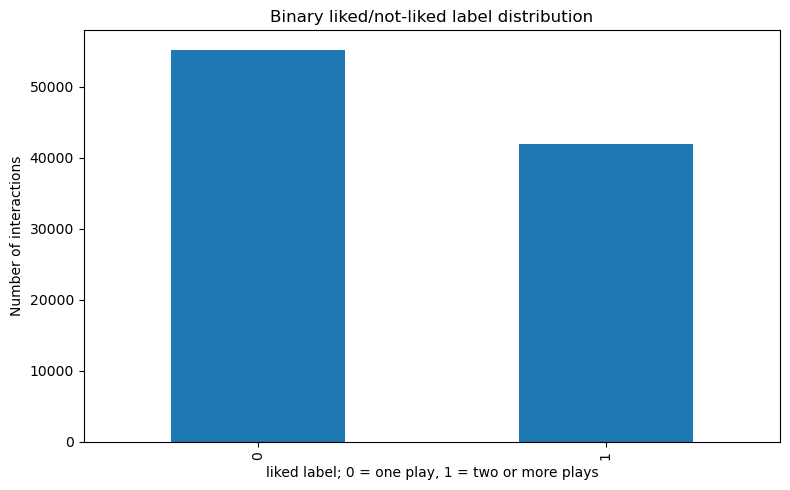

In [16]:
# Plot the transformed rating-like score.
# The distribution shows how the implicit play counts were converted into a bounded 1-5 scale.
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(model_interactions["rating"], bins=50)
ax.set_title("Rating-like preference score after clipping and log scaling")
ax.set_xlabel("rating")
ax.set_ylabel("Number of interactions")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "phase1_rating_distribution.png", dpi=150)
plt.show()

# Plot the binary liked/not-liked label.
# This checks whether the repeated-listen label is too imbalanced for ROC/AUC evaluation.
fig, ax = plt.subplots(figsize=(8, 5))
model_interactions["liked"].value_counts().sort_index().plot(kind="bar", ax=ax)
ax.set_title("Binary liked/not-liked label distribution")
ax.set_xlabel("liked label; 0 = one play, 1 = two or more plays")
ax.set_ylabel("Number of interactions")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "phase1_liked_label_distribution.png", dpi=150)
plt.show()

### Observation for report

The 99th percentile clipping threshold for the modelling sample is 25 plays. This means that play counts above 25 are capped before the log transformation is applied. The original maximum play count in the modelling sample is 319, so clipping meaningfully reduces the influence of extreme listening events.

After clipping and log scaling, the rating-like preference score ranges from 1 to 5. The distribution is still concentrated toward the lower end because most observed interactions are low-play events. This is expected for implicit music feedback. A rating of 1 should not be interpreted as an explicit dislike; it represents the weakest observed positive signal, usually a single play.

The binary `liked` label is created by treating interactions with two or more plays as repeated-listen positives. In the modelling sample, about 43% of interactions are labelled as liked. This gives a reasonably usable class balance for later ROC curve and AUC evaluation.

## 1.8 Add readable song metadata

The models only need `user_id`, `song_id`, and `rating`, but the final Top 10 playlists and report examples should show readable song titles and artists. I therefore merge the interaction-based modelling data with the full song metadata table.

All songs in the modelling data have matching metadata. This means the recommendation examples can be displayed with song titles and artist names instead of relying on `song_id` values only.


In [17]:
# Keep one metadata row per song_id.
# Duplicate metadata rows are removed so the merge does not accidentally duplicate interactions.
songs_clean = songs.drop_duplicates(subset=["song_id"]).copy()

# Merge metadata into the modelling data.
# The indicator column makes it possible to verify metadata coverage after the merge.
model_data = model_interactions.merge(
    songs_clean,
    on="song_id",
    how="left",
    indicator=True
)

# Store whether metadata was available before filling any missing display fields.
# This should be 100% for the modelling data when all interacted songs have matching metadata.
model_data["metadata_available"] = model_data["_merge"].eq("both")
model_data = model_data.drop(columns=["_merge"])

# Fill any remaining missing display fields.
# This is mainly a safety step for rare missing title/release values, not a replacement for metadata coverage.
model_data["title"] = model_data["title"].fillna("Unknown title")
model_data["release"] = model_data["release"].fillna("Unknown release")
model_data["artist_name"] = model_data["artist_name"].fillna("Unknown artist")
model_data["year"] = model_data["year"].fillna(0).astype(int)

print("Model data shape after metadata merge:", model_data.shape)
display(model_data.head())

metadata_coverage_model = model_data["metadata_available"].mean() * 100
print("Metadata coverage in modelling data:", round(metadata_coverage_model, 2), "%")


Model data shape after metadata merge: (97215, 12)


,user_id,song_id,play_count,play_count_clipped,play_count_log,rating,liked,title,release,artist_name,year,metadata_available
0,e006b1a48f466bf59feefed32bec6494495a4436,SOAUWYT12A81C206F1,2,2,1.098612,1.632317,1,Undo,Vespertine Live,Björk,2001,True
1,e006b1a48f466bf59feefed32bec6494495a4436,SOAXGDH12A8C13F8A1,2,2,1.098612,1.632317,1,Dog Days Are Over (Radio Edit),Now That's What I Call Music! 75,Florence + The Machine,0,True
2,e006b1a48f466bf59feefed32bec6494495a4436,SOBFMHC12A6D4F9401,1,1,0.693147,1.000000,0,High Life,Discovery,Daft Punk,2001,True
3,e006b1a48f466bf59feefed32bec6494495a4436,SOBONKR12A58A7A7E0,2,2,1.098612,1.632317,1,You're The One,If There Was A Way,Dwight Yoakam,1990,True
4,e006b1a48f466bf59feefed32bec6494495a4436,SOBTRCD12A6701E976,2,2,1.098612,1.632317,1,Where Did You Sleep Last Night,MTV Unplugged In New York,Nirvana,0,True


Metadata coverage in modelling data: 100.0 %


### Observation for report

The metadata merge gives 100% metadata coverage for the modelling data. This means every user-song interaction in the modelling sample can be connected to a metadata row with title, release, artist name, and year information.

The collaborative-filtering models still mainly use `user_id`, `song_id`, and the transformed `rating`, because the core task is to learn from user-song interaction patterns. However, the metadata is now reliable enough to make the final recommendation examples readable without needing separate metadata-filtered presentation tables.


## 1.9 Export Phase 1 outputs

These files are useful for the next phases and for the technical report:

- `phase1_model_data.csv`: cleaned modelling dataset with rating-like scores.
- `phase1_song_metadata_clean.csv`: cleaned metadata table.
- `phase1_filtering_threshold_comparison.csv`: filtering comparison table for the report.
- Phase 1 figures in the `figures/` folder.

In [18]:
# Export the cleaned modelling dataset.
# This file is the main input for Phase 2 model development.
model_data.to_csv(
    OUTPUTS_DIR / "phase1_model_data.csv",
    index=False
)

# Export the cleaned metadata table.
# This can be reused later when displaying recommendation results.
songs_clean.to_csv(
    OUTPUTS_DIR / "phase1_song_metadata_clean.csv",
    index=False
)

# Create a compact Phase 1 summary for the technical report.
# These values document the main preprocessing decisions and resulting dataset sizes.
phase1_summary = {
    "raw_interactions": len(interactions),
    "raw_users": interactions["user_id"].nunique(),
    "raw_songs": interactions["song_id"].nunique(),
    "raw_sparsity": raw_sparsity["sparsity"],
    "raw_density": raw_sparsity["density"],
    "raw_sparsity_%": raw_sparsity["sparsity_%"],
    "raw_density_%": raw_sparsity["density_%"],

    "filtered_full_interactions": len(filtered_full),
    "filtered_full_users": filtered_full["user_id"].nunique(),
    "filtered_full_songs": filtered_full["song_id"].nunique(),
    "filtered_full_sparsity": filtered_full_sparsity.loc[0, "sparsity"],
    "filtered_full_density": filtered_full_sparsity.loc[0, "density"],
    "filtered_full_sparsity_%": filtered_full_sparsity.loc[0, "sparsity_%"],
    "filtered_full_density_%": filtered_full_sparsity.loc[0, "density_%"],

    "model_interactions": len(model_data),
    "model_users": model_data["user_id"].nunique(),
    "model_songs": model_data["song_id"].nunique(),
    "model_sparsity": model_sparsity.loc[0, "sparsity"],
    "model_density": model_sparsity.loc[0, "density"],
    "model_sparsity_%": model_sparsity.loc[0, "sparsity_%"],
    "model_density_%": model_sparsity.loc[0, "density_%"],

    "clip_quantile": OUTLIER_CLIP_QUANTILE,
    "clip_value": clip_value,
    "rating_min": model_data["rating"].min(),
    "rating_max": model_data["rating"].max(),
    "rating_mean": model_data["rating"].mean(),
    "liked_positive_rate": model_data["liked"].mean(),
    "metadata_coverage_%": metadata_coverage_model,
}

phase1_summary_df = pd.DataFrame([phase1_summary])

# Export the summary table so the report can reuse exact preprocessing numbers.
phase1_summary_df.to_csv(
    OUTPUTS_DIR / "phase1_summary.csv",
    index=False
)

display(phase1_summary_df.T.rename(columns={0: "value"}))

,value
raw_interactions,2.000000e+06
raw_users,7.635300e+04
raw_songs,1.000000e+04
raw_sparsity,9.973806e-01
raw_density,2.619412e-03
raw_sparsity_%,9.973806e+01
raw_density_%,2.619412e-01
filtered_full_interactions,1.504680e+06
filtered_full_users,3.080000e+04
filtered_full_songs,9.399000e+03


## 1.10 Conclusion (Phase 1)

Phase 1 prepared the data for recommender modelling. The main conclusions are:

- The interaction matrix is highly sparse, which is expected in a recommender-system setting. The raw matrix is about 99.74% sparse.
- Play counts are strongly long-tailed. Raw counts are therefore not suitable as direct ratings without clipping and transformation.
- User activity is uneven. Many users have limited listening histories, while a small number of users have much richer histories.
- Song popularity is also long-tailed. This means a popularity baseline is useful, especially as a cold-start fallback, but it can also over-recommend mainstream songs.
- Moderate filtering was used to remove the sparsest users and songs while keeping enough data for model comparison.
- A reproducible user-sampled modelling dataset was created to make KNN, SVD, Co-Clustering, and ensemble experiments computationally feasible.
- Extreme play counts were clipped at the 99th percentile and log-scaled into a 1-5 rating-like score for compatibility with classical recommender algorithms.
- The rating-like score should be interpreted as preference strength among observed interactions, not as explicit star ratings.
- A binary repeated-listen label was created for later ROC/AUC evaluation.
- The metadata provides complete coverage for the modelling data, so recommendation examples can be shown with readable song titles and artist names.

The next phase will train and compare a popularity baseline, KNN collaborative filtering, SVD matrix factorization, Co-Clustering, and a weighted-average ensemble model.


---

# Phase 2 - Model Development

This section implements the required recommendation models from the project brief:

1. A non-personalized popularity-based baseline.
2. Memory-based collaborative filtering using item-item k-nearest neighbours.
3. Matrix factorization using SVD.
4. Co-Clustering as an unsupervised user-item grouping method.
5. A weighted ensemble that combines the model scores.

I train the models on the cleaned Phase 1 modelling dataset. Surprise is appropriate here because it provides ready-to-use KNN, SVD, and Co-Clustering algorithms for user-item-rating experiments. However, the ratings in this project are transformed implicit-feedback scores rather than true explicit star ratings, so the results must be interpreted as preference-strength estimates rather than literal star ratings.

In [19]:
# Phase 2 imports.
# Surprise is used for classical recommender algorithms such as KNN, SVD, and Co-Clustering.
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

from surprise import Dataset, Reader, accuracy
from surprise import KNNWithMeans, SVD, CoClustering

## 2.1 Prepare the modelling data

The cleaned Phase 1 output is loaded and split into training, validation, and test sets.

I use three splits instead of only train/test because the validation set is needed for model comparison and ensemble-weight selection. The final test set is kept separate for the final Phase 3 evaluation. This gives a more defensible evaluation workflow because model choices are not tuned directly on the final test set.

All models will use the same split, so their results remain comparable.

In [20]:
# Keep the columns needed for model training, validation, testing, and readable output.
# user_id and song_id are kept as strings because Surprise treats raw IDs as identifiers.
phase2_data = model_data[
    [
        "user_id", "song_id", "rating", "liked", "play_count",
        "title", "artist_name", "release", "year", "metadata_available"
    ]
].copy()

phase2_data["user_id"] = phase2_data["user_id"].astype(str)
phase2_data["song_id"] = phase2_data["song_id"].astype(str)

# Create a train/validation/test split.
# Train is used to fit models, validation is used for model comparison and ensemble choices,
# and test is kept for the final Phase 3 evaluation.
TRAIN_SIZE = 0.70
VAL_SIZE = 0.15
TEST_SIZE = 0.15

# First split off the final test set.
# Stratifying by liked keeps the repeated-listen label distribution similar across splits.
train_val_df, test_df = train_test_split(
    phase2_data,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=phase2_data["liked"],
)

# Then split the remaining data into train and validation.
# The relative validation size is calculated because this split is applied after removing the test set.
relative_val_size = VAL_SIZE / (TRAIN_SIZE + VAL_SIZE)

train_df, val_df = train_test_split(
    train_val_df,
    test_size=relative_val_size,
    random_state=RANDOM_STATE,
    stratify=train_val_df["liked"],
)

print("Phase 2 train shape:", train_df.shape)
print("Phase 2 validation shape:", val_df.shape)
print("Phase 2 test shape:", test_df.shape)

print("\nTrain users:", train_df["user_id"].nunique())
print("Validation users:", val_df["user_id"].nunique())
print("Test users:", test_df["user_id"].nunique())

print("\nTrain songs:", train_df["song_id"].nunique())
print("Validation songs:", val_df["song_id"].nunique())
print("Test songs:", test_df["song_id"].nunique())

# Check whether validation or test contains users or songs that are unseen in training.
# Surprise can produce fallback predictions for unknown users/items, but this should still be reported.
unknown_val_users = set(val_df["user_id"]) - set(train_df["user_id"])
unknown_val_songs = set(val_df["song_id"]) - set(train_df["song_id"])

unknown_test_users = set(test_df["user_id"]) - set(train_df["user_id"])
unknown_test_songs = set(test_df["song_id"]) - set(train_df["song_id"])

print("\nUnknown validation users:", len(unknown_val_users))
print("Unknown validation songs:", len(unknown_val_songs))
print("Unknown test users:", len(unknown_test_users))
print("Unknown test songs:", len(unknown_test_songs))

print("\nTrain liked positive rate:", round(train_df["liked"].mean(), 3))
print("Validation liked positive rate:", round(val_df["liked"].mean(), 3))
print("Test liked positive rate:", round(test_df["liked"].mean(), 3))

Phase 2 train shape: (68049, 10)
Phase 2 validation shape: (14583, 10)
Phase 2 test shape: (14583, 10)

Train users: 2174
Validation users: 2155
Test users: 2157

Train songs: 4128
Validation songs: 3789
Test songs: 3786

Unknown validation users: 0
Unknown validation songs: 0
Unknown test users: 0
Unknown test songs: 0

Train liked positive rate: 0.432
Validation liked positive rate: 0.432
Test liked positive rate: 0.432


### Observation for report

The dataset is split into training, validation, and test sets. I use the training set to fit the models, the validation set to compare model behaviour and choose ensemble weights, and the test set later for the final Phase 3 evaluation.

This is more defensible than using only a train/test split, because the final test set should represent unseen data after modelling decisions have already been made. The split is still random rather than temporal, so it should be interpreted as an offline benchmark rather than a perfect simulation of future listening behaviour. Offline evaluation is useful for comparing candidate recommenders, but it mainly measures how well historical held-out interactions can be predicted.

## 2.2 Popularity-based baseline

The popularity model is non-personalized. It is important both as a baseline benchmark and as a cold-start fallback.

For existing users, more advanced models should ideally improve beyond popularity by personalizing recommendations. For a completely new user with no listening history, however, collaborative filtering cannot infer personal preferences yet. In that case, a popularity-based recommender is a practical fallback strategy.

Cold-start literature also supports using simple heuristic recommenders as meaningful baselines rather than comparing only against random recommendation.

In [21]:
def calculate_rmse(y_true, y_pred):
    """
    Calculate RMSE in a version-safe way.

    Some scikit-learn versions do not support squared=False in mean_squared_error,
    so I calculate the square root manually.
    """
    return np.sqrt(mean_squared_error(y_true, y_pred))

In [22]:
class PopularityRecommender:
    """
    Non-personalized popularity-based recommender.

    The model learns item-level statistics from the training data. It can predict a
    rating-like score for any known song, and falls back to the global mean for
    unknown songs. It can also return a global Top N list for cold-start users.
    """

    def __init__(self, smoothing=20):
        self.smoothing = smoothing
        self.global_mean_ = None
        self.item_stats_ = None


    def fit(self, df):
        # Store the global mean rating as a fallback for unknown songs.
        self.global_mean_ = df["rating"].mean()

        # Aggregate training interactions per song.
        # The sum of ratings is used for Bayesian smoothing, while total plays supports popularity ranking.
        item_stats = (
            df.groupby("song_id")
            .agg(
                n_interactions=("user_id", "count"),
                n_users=("user_id", "nunique"),
                total_plays=("play_count", "sum"),
                mean_rating=("rating", "mean"),
                rating_sum=("rating", "sum"),
            )
            .reset_index()
        )

        # Bayesian-smoothed rating estimate.
        # This pulls low-count songs toward the global mean and reduces noise from rare items.
        item_stats["popularity_pred"] = (
            item_stats["rating_sum"] + self.smoothing * self.global_mean_
        ) / (item_stats["n_interactions"] + self.smoothing)

        # Scale log total plays to a 1-5 range for ranking purposes.
        # This makes high-volume songs more visible without letting raw play counts dominate.
        log_plays = np.log1p(item_stats["total_plays"])

        if log_plays.max() > log_plays.min():
            item_stats["play_volume_score"] = 1 + 4 * (
                (log_plays - log_plays.min()) / (log_plays.max() - log_plays.min())
            )
        else:
            item_stats["play_volume_score"] = self.global_mean_

        # Final non-personalized ranking score for Top N recommendations.
        # The larger weight on smoothed rating keeps the score preference-oriented,
        # while the play-volume component makes the baseline useful for cold start.
        item_stats["popularity_rank_score"] = (
            0.70 * item_stats["popularity_pred"] +
            0.30 * item_stats["play_volume_score"]
        )

        self.item_stats_ = item_stats.set_index("song_id")
        return self


    def predict_many(self, df):
        # Vectorized prediction for a dataframe containing song_id.
        # Songs unseen during training receive the global mean rating-like score.
        return (
            df["song_id"]
            .map(self.item_stats_["popularity_pred"])
            .fillna(self.global_mean_)
        )


    def recommend_top_n(self, n=10, exclude_items=None, metadata_df=None):
        # Recommend the globally strongest songs, optionally excluding songs already seen by a user.
        exclude_items = set(exclude_items or [])

        recs = (
            self.item_stats_
            .reset_index()
            .loc[lambda x: ~x["song_id"].isin(exclude_items)]
            .sort_values("popularity_rank_score", ascending=False)
            .head(n)
            .copy()
        )

        if metadata_df is not None:
            recs = recs.merge(metadata_df, on="song_id", how="left")

        return recs

In [23]:
def evaluate_popularity_model(model, split_df, split_name):
    """
    Evaluate the popularity model on a validation or test split.

    The returned dataframe is kept for later ranking metrics and ROC/AUC evaluation.
    """
    prediction_df = split_df[["user_id", "song_id", "rating", "liked"]].copy()
    prediction_df = prediction_df.rename(columns={"rating": "actual_rating"})

    # Predict rating-like preference scores using only song-level popularity learned from training.
    prediction_df["popularity_pred"] = model.predict_many(split_df)

    rmse = calculate_rmse(
        prediction_df["actual_rating"],
        prediction_df["popularity_pred"],
    )

    print(f"Popularity baseline {split_name} RMSE:", round(rmse, 4))

    return prediction_df, rmse

In [24]:
# Train the popularity baseline on the training split only.
# Validation and test data are kept unseen during fitting.
start_fit = time.time()
popularity_model = PopularityRecommender(smoothing=20).fit(train_df)
popularity_fit_time = time.time() - start_fit

# Evaluate on the validation split for model comparison.
# The validation prediction table will later be merged with the other validation predictions.
start_val = time.time()
popularity_val_prediction_df, popularity_val_rmse = evaluate_popularity_model(
    popularity_model,
    val_df,
    split_name="validation",
)
popularity_val_time = time.time() - start_val

# Store the popularity result using the same column names as the later validation-based models.
phase2_model_results = [{
    "model": "Popularity Baseline",
    "model_key": "popularity",
    "model_type": "Non-personalized baseline",
    "validation_rmse": popularity_val_rmse,
    "fit_time_seconds": popularity_fit_time,
    "validation_time_seconds": popularity_val_time,
}]

print("Popularity baseline fit time:", round(popularity_fit_time, 4), "seconds")

# Store one metadata row per song for readable recommendation examples.
# This is used only for presentation, not for fitting the collaborative models.
song_display_metadata = (
    model_data[["song_id", "title", "artist_name", "release", "year", "metadata_available"]]
    .drop_duplicates(subset=["song_id"])
)

# Show the cold-start Top 10 playlist produced by the popularity baseline.
# This demonstrates how the baseline can serve users with no listening history.
cold_start_top10 = popularity_model.recommend_top_n(
    n=10,
    metadata_df=song_display_metadata,
)

display(
    cold_start_top10[
        ["song_id", "title", "artist_name", "n_users", "total_plays", "popularity_rank_score"]
    ]
)

Popularity baseline validation RMSE: 0.91
Popularity baseline fit time: 0.0607 seconds


,song_id,title,artist_name,n_users,total_plays,popularity_rank_score
0,SOBONKR12A58A7A7E0,You're The One,Dwight Yoakam,206,2369,3.297958
1,SOAUWYT12A81C206F1,Undo,Björk,252,1850,3.103190
2,SOSXLTC12AF72A7F54,Revelry,Kings Of Leon,235,1864,3.015751
3,SORJICW12A8C13640D,Mercy:The Laundromat,Pavement,68,567,2.919639
4,SOEGIYH12A6D4FC0E3,Horn Concerto No. 4 in E flat K495: II. Romanc...,Barry Tuckwell/Academy of St Martin-in-the-Fie...,175,1214,2.905860
5,SOUFTBI12AB0183F65,Invalid,Tub Ring,118,918,2.866850
6,SOAXGDH12A8C13F8A1,Dog Days Are Over (Radio Edit),Florence + The Machine,306,1353,2.806427
7,SOFRQTD12A81C233C0,Sehr kosmisch,Harmonia,315,1306,2.780714
8,SOBOUPA12A6D4F81F1,Sincerité Et Jalousie,Alliance Ethnik,106,658,2.779462
9,SOVIZNF12AF72A710A,The Big Gundown,The Prodigy,23,266,2.778980


### Observation for report

The popularity baseline provides a simple but meaningful benchmark. It is non-personalized, so every new user receives the same global Top 10 list unless additional onboarding or demographic information is added later.

The model uses Bayesian smoothing so that songs with very few interactions are pulled toward the global average. This reduces the risk that a song with only a small number of unusually high ratings becomes over-ranked. The final popularity ranking combines smoothed rating strength with total play volume, which makes it suitable as a cold-start fallback.

This model is not expected to be the best personalized recommender, but it is important because more complex models should be compared against a competent simple baseline.

## 2.3 Prepare Surprise data and helpers

Surprise expects user-item-rating triples. The training dataframe is converted into a Surprise trainset, while the validation and test dataframes are converted into lists of raw user ID, item ID, and true rating triples.

In this phase, I use the validation set for model comparison and ensemble-weight decisions. The final test set is prepared but reserved for Phase 3.

In [25]:
# Surprise expects exactly three columns in this order: user ID, item ID, and rating.
# The rating scale is set to 1-5 because Phase 1 transformed implicit play counts into this bounded range.
reader = Reader(rating_scale=(1, 5))

# Convert the training dataframe into a Surprise Dataset object.
# Only the training split is used here, so validation and test interactions stay unseen during fitting.
surprise_train_data = Dataset.load_from_df(
    train_df[["user_id", "song_id", "rating"]],
    reader
)

# Build the internal Surprise trainset.
# Surprise maps raw user/song IDs to internal integer IDs for efficient model training.
surprise_trainset = surprise_train_data.build_full_trainset()

# Convert the validation dataframe into a Surprise testset format.
# This is used for Phase 2 model comparison and ensemble-weight selection.
surprise_val_testset = list(
    val_df[["user_id", "song_id", "rating"]]
    .itertuples(index=False, name=None)
)

# Convert the final test dataframe into the same Surprise testset format.
# This is intentionally kept separate for Phase 3 final evaluation.
surprise_final_testset = list(
    test_df[["user_id", "song_id", "rating"]]
    .itertuples(index=False, name=None)
)

print("Surprise training ratings:", surprise_trainset.n_ratings)
print("Surprise validation triples:", len(surprise_val_testset))
print("Surprise final test triples:", len(surprise_final_testset))

Surprise training ratings: 68049
Surprise validation triples: 14583
Surprise final test triples: 14583


In [26]:
def surprise_predictions_to_df(predictions, model_key):
    """
    Convert Surprise Prediction objects into a dataframe.

    The dataframe keeps the raw user ID, raw song ID, true rating, and estimated rating.
    This makes it easier to merge predictions across models for ensemble construction.
    """
    return pd.DataFrame([
        {
            "user_id": pred.uid,
            "song_id": pred.iid,
            "actual_rating": pred.r_ui,
            f"{model_key}_pred": pred.est,
        }
        for pred in predictions
    ])

In [27]:
def fit_and_evaluate_surprise_model(model_name, model_key, model_type, algo, trainset, validation_testset):
    """
    Fit a Surprise algorithm and evaluate it on the validation set.

    The validation set is used in Phase 2 because model comparison and ensemble decisions
    should not be tuned directly on the final test set.
    """
    # Fit the algorithm on the Surprise trainset.
    start_fit = time.time()
    algo.fit(trainset)
    fit_time = time.time() - start_fit

    # Generate predictions for the shared validation set.
    start_val = time.time()
    predictions = algo.test(validation_testset)
    validation_time = time.time() - start_val

    # Calculate validation RMSE using Surprise's built-in RMSE implementation.
    validation_rmse = accuracy.rmse(predictions, verbose=False)

    # Convert predictions to a dataframe so they can be merged for the ensemble.
    prediction_df = surprise_predictions_to_df(predictions, model_key)

    result = {
        "model": model_name,
        "model_key": model_key,
        "model_type": model_type,
        "validation_rmse": validation_rmse,
        "fit_time_seconds": fit_time,
        "validation_time_seconds": validation_time,
    }

    print(f"{model_name} validation RMSE: {validation_rmse:.4f}")
    print(f"{model_name} fit time: {fit_time:.2f}s")
    print(f"{model_name} validation prediction time: {validation_time:.2f}s")

    return algo, result, prediction_df

## 2.4 Item-item KNN collaborative filtering

KNN is the memory-based collaborative-filtering model. It predicts preferences from neighbouring users or neighbouring items. I use item-item KNN because songs are more stable than users, and because item-item similarity is easier to interpret as “users who listened to this song also listened to similar songs.”

In Surprise, `sim_options["user_based"] = False` means that the neighbourhoods are built between items rather than between users.

In [28]:
# Item-item KNN with mean-centering.
# KNNWithMeans adjusts for rating-scale differences before applying neighbourhood prediction.
item_knn = KNNWithMeans(
    k=30,
    min_k=3,
    sim_options={
        # Cosine similarity compares songs by their user-rating patterns.
        "name": "cosine",

        # False means item-item KNN instead of user-user KNN.
        "user_based": False,

        # At least three overlapping users are required before a similarity is considered reliable.
        "min_support": 3,
    },
    verbose=False,
)

# Fit the item-item KNN model and evaluate it on the validation set.
item_knn, item_knn_result, item_knn_val_prediction_df = fit_and_evaluate_surprise_model(
    model_name="Item-Item KNN",
    model_key="item_knn",
    model_type="Memory-based collaborative filtering",
    algo=item_knn,
    trainset=surprise_trainset,
    validation_testset=surprise_val_testset,
)

# Store the result for the Phase 2 validation comparison table.
phase2_model_results.append(item_knn_result)

Item-Item KNN validation RMSE: 0.8617
Item-Item KNN fit time: 1.42s
Item-Item KNN validation prediction time: 1.20s


## 2.5 Matrix factorization with SVD

SVD learns latent user and item factors. The idea is that both users and songs can be represented in a shared hidden factor space, and the model estimates preference from the interaction between a user vector and a song vector.

This is useful for sparse recommender data because the model can generalize from observed user-song interactions to unobserved combinations. Regularization is important because the matrix is sparse and the model should not simply memorize the training interactions.

In [29]:
# SVD matrix factorization.
# n_factors controls the size of the latent user/song representation.
# n_epochs controls how many passes the optimizer makes over the training ratings.
# reg_all applies regularization to reduce overfitting on the sparse rating-like matrix.
svd_model = SVD(
    n_factors=50,
    n_epochs=20,
    lr_all=0.005,
    reg_all=0.05,
    random_state=RANDOM_STATE,
)

# Fit the SVD model and evaluate it on the validation set.
svd_model, svd_result, svd_val_prediction_df = fit_and_evaluate_surprise_model(
    model_name="SVD Matrix Factorization",
    model_key="svd",
    model_type="Latent factor model",
    algo=svd_model,
    trainset=surprise_trainset,
    validation_testset=surprise_val_testset,
)

# Store the result for the Phase 2 validation comparison table.
phase2_model_results.append(svd_result)

SVD Matrix Factorization validation RMSE: 0.8194
SVD Matrix Factorization fit time: 0.94s
SVD Matrix Factorization validation prediction time: 0.16s


## 2.6 Co-Clustering

Co-Clustering groups users and songs simultaneously. Instead of only clustering users or only clustering songs, it searches for block-like structure in the user-song matrix. In this project, that can be interpreted as groups of users who show similar listening behaviour toward groups of songs.

I use it as the required unsupervised learning component. It is not expected to be the most accurate model, but it adds a different structural perspective to the ensemble.

In [30]:
# Co-Clustering groups users and songs simultaneously.
# The number of user and item clusters is kept moderate to avoid overfitting and long runtime.
coclustering_model = CoClustering(
    n_cltr_u=5,
    n_cltr_i=5,
    n_epochs=20,
    random_state=RANDOM_STATE,
)

# Fit the Co-Clustering model and evaluate it on the validation set.
coclustering_model, coclustering_result, coclustering_val_prediction_df = fit_and_evaluate_surprise_model(
    model_name="Co-Clustering",
    model_key="coclustering",
    model_type="Unsupervised co-clustering",
    algo=coclustering_model,
    trainset=surprise_trainset,
    validation_testset=surprise_val_testset,
)

# Store the result for the Phase 2 validation comparison table.
phase2_model_results.append(coclustering_result)

Co-Clustering validation RMSE: 0.8994
Co-Clustering fit time: 3.59s
Co-Clustering validation prediction time: 0.09s


## 2.7 Ensemble model

The ensemble combines the validation predictions from the popularity baseline, item-item KNN, SVD, and Co-Clustering.

The weights are logic-based:

- SVD: **0.40**, because it is the strongest latent-factor model and is expected to generalize well in sparse data.
- Item-item KNN: **0.25**, because it adds local song-similarity information.
- Co-Clustering: **0.20**, because it adds broad user-song group structure.
- Popularity: **0.15**, because it is a stable non-personalized fallback and helps anchor the ensemble.

These weights are intentionally simple and interpretable. I choose them on the validation set, not on the final test set. Phase 3 will use the final test set to evaluate the selected strategy.

In [31]:
# Merge all validation predictions on the same held-out validation interactions.
# Each row contains the true validation rating and one prediction column per model.
phase2_val_prediction_df = popularity_val_prediction_df.merge(
    item_knn_val_prediction_df,
    on=["user_id", "song_id", "actual_rating"],
    how="inner",
).merge(
    svd_val_prediction_df,
    on=["user_id", "song_id", "actual_rating"],
    how="inner",
).merge(
    coclustering_val_prediction_df,
    on=["user_id", "song_id", "actual_rating"],
    how="inner",
)

# Keep the liked label from the validation split for later ROC/AUC and ranking metrics.
# This is useful because the Surprise prediction objects only carry the rating, not the binary label.
phase2_val_prediction_df = phase2_val_prediction_df.merge(
    val_df[["user_id", "song_id", "liked"]],
    on=["user_id", "song_id"],
    how="left",
)

# Logic-based ensemble weights.
# The weights sum to 1 and reflect the expected contribution of each model type.
ensemble_weights = {
    "popularity_pred": 0.15,
    "item_knn_pred": 0.25,
    "svd_pred": 0.40,
    "coclustering_pred": 0.20,
}

# Normalize the weights as a safety check.
# This prevents mistakes if the dictionary is edited later.
weight_sum = sum(ensemble_weights.values())
ensemble_weights = {
    pred_col: weight / weight_sum
    for pred_col, weight in ensemble_weights.items()
}

# Combine the component predictions into one ensemble score.
# The final score is clipped to the valid 1-5 rating-like range.
phase2_val_prediction_df["ensemble_pred"] = sum(
    weight * phase2_val_prediction_df[pred_col]
    for pred_col, weight in ensemble_weights.items()
).clip(1, 5)

# Calculate validation RMSE using the version-safe helper from section 2.2.
ensemble_val_rmse = calculate_rmse(
    phase2_val_prediction_df["actual_rating"],
    phase2_val_prediction_df["ensemble_pred"],
)

# Add the ensemble result to the shared Phase 2 comparison table.
phase2_model_results.append({
    "model": "Weighted Ensemble",
    "model_key": "ensemble",
    "model_type": "Advanced ensemble strategy",
    "validation_rmse": ensemble_val_rmse,
    "fit_time_seconds": np.nan,
    "validation_time_seconds": np.nan,
})

# Create a clean validation comparison table.
phase2_model_results_df = (
    pd.DataFrame(phase2_model_results)
    .sort_values("validation_rmse")
    .reset_index(drop=True)
)

print("Weighted Ensemble validation RMSE:", round(ensemble_val_rmse, 4))
display(phase2_model_results_df)

# Save validation predictions and validation model results.
# These files document the Phase 2 model-selection stage.
phase2_val_prediction_df.to_csv(
    OUTPUTS_DIR / "phase2_validation_predictions.csv",
    index=False,
)

phase2_model_results_df.to_csv(
    OUTPUTS_DIR / "phase2_validation_model_results.csv",
    index=False,
)

# Save the ensemble weights for the technical report.
ensemble_weights_df = pd.DataFrame([
    {"prediction_column": pred_col, "weight": weight}
    for pred_col, weight in ensemble_weights.items()
])

ensemble_weights_df.to_csv(
    OUTPUTS_DIR / "phase2_ensemble_weights.csv",
    index=False,
)

display(ensemble_weights_df)

Weighted Ensemble validation RMSE: 0.8202


,model,model_key,model_type,validation_rmse,fit_time_seconds,validation_time_seconds
0,SVD Matrix Factorization,svd,Latent factor model,0.819402,0.942892,0.158690
1,Weighted Ensemble,ensemble,Advanced ensemble strategy,0.820247,NaN,NaN
2,Item-Item KNN,item_knn,Memory-based collaborative filtering,0.861679,1.422917,1.196908
3,Co-Clustering,coclustering,Unsupervised co-clustering,0.899368,3.585481,0.085044
4,Popularity Baseline,popularity,Non-personalized baseline,0.909994,0.060674,0.010966


,prediction_column,weight
0,popularity_pred,0.15
1,item_knn_pred,0.25
2,svd_pred,0.40
3,coclustering_pred,0.20


### Observation for report

The validation RMSE comparison provides the first model-development benchmark. The popularity baseline is useful as a cold-start fallback, but it is non-personalized. Item-item KNN, SVD, and Co-Clustering use collaborative information from the user-song matrix and can therefore personalize beyond simple popularity.

SVD is the strongest individual model on validation RMSE. It achieves a validation RMSE of about 0.8194, while the weighted ensemble achieves about 0.8202. This means the ensemble does not improve RMSE compared with SVD, although the difference is very small.

I still keep the ensemble as the required advanced strategy because it combines complementary signals: SVD contributes latent-factor structure, item-item KNN contributes local song similarity, Co-Clustering contributes broad user-song group structure, and popularity contributes a stable fallback signal. In Phase 3, I will evaluate whether the ensemble provides benefits for ranking metrics such as Recall@K, not only RMSE.

The final test set is not used in this phase. It is reserved for Phase 3, where the selected models will be evaluated with RMSE, ROC/AUC, and ranking metrics.

## 2.8 Generate example Top 10 playlists

This subsection demonstrates how the trained models can generate recommendation lists.

The validation RMSE comparison shows that SVD is the strongest model so far. Therefore, I use SVD as the selected personalized recommendation model in this section. I still keep the ensemble score in the output because the ensemble is the required advanced strategy and will be evaluated further in Phase 3 with ranking metrics such as Recall@K.

I show two recommendation tables:

1. A personalized SVD Top 10 playlist for an existing user.
2. A popularity-based Top 10 playlist for a cold-start user.

Separate metadata-filtered presentation tables are not needed because the modelling data already has complete metadata coverage.


In [32]:
def add_readable_metadata(recommendations, metadata_df):
    """
    Add title and artist information to a recommendation table.

    The modelling data has complete metadata coverage, so this function is mainly
    used to attach readable display fields to scored songs.
    """
    return recommendations.merge(metadata_df, on="song_id", how="left")

In [33]:
def score_candidate_songs_for_user(user_id):
    """
    Score all training-catalogue songs that the selected user has not seen in training.

    This function returns the full candidate table before selecting the Top N.
    Keeping the full table makes it possible to compare SVD and ensemble scores
    while still ranking by the selected model.
    """
    # Identify songs already observed for this user in the training split.
    # These songs are excluded because recommendations should focus on unseen items.
    seen_items = set(train_df.loc[train_df["user_id"] == user_id, "song_id"])

    # Use the training catalogue as the candidate pool.
    # This avoids recommending songs that were never available during model fitting.
    all_train_items = sorted(train_df["song_id"].unique())
    candidate_items = [item for item in all_train_items if item not in seen_items]

    # Build a candidate dataframe with one row per unseen song.
    candidate_scores = pd.DataFrame({"song_id": candidate_items})
    candidate_scores["user_id"] = user_id

    # Score each candidate with all component models.
    # SVD is the current selected model by validation RMSE, while the other scores
    # remain useful for interpreting the ensemble and later Phase 3 evaluation.
    candidate_scores["popularity_pred"] = popularity_model.predict_many(candidate_scores)
    candidate_scores["item_knn_pred"] = [
        item_knn.predict(user_id, song_id).est for song_id in candidate_items
    ]
    candidate_scores["svd_pred"] = [
        svd_model.predict(user_id, song_id).est for song_id in candidate_items
    ]
    candidate_scores["coclustering_pred"] = [
        coclustering_model.predict(user_id, song_id).est for song_id in candidate_items
    ]

    # Calculate the weighted-average ensemble score from section 2.7.
    # This keeps the advanced strategy available without treating it as the best RMSE model.
    candidate_scores["ensemble_score"] = sum(
        weight * candidate_scores[pred_col]
        for pred_col, weight in ensemble_weights.items()
    ).clip(1, 5)

    # Attach readable metadata for final playlist display.
    candidate_scores = add_readable_metadata(candidate_scores, song_display_metadata)

    return candidate_scores

In [34]:
def recommend_for_existing_user(user_id, n=10, score_column="svd_pred"):
    """
    Generate a Top N playlist for an existing user.

    score_column controls which model is used for ranking. I use svd_pred as the
    default because SVD is currently the best validation-RMSE model.
    """
    candidate_scores = score_candidate_songs_for_user(user_id)

    top_n = (
        candidate_scores
        .sort_values(score_column, ascending=False)
        .head(n)
        .copy()
    )

    return top_n

In [35]:
def cold_start_top_n(popularity_model, n=10, metadata_df=None):
    """
    Generate a cold-start Top N playlist from the popularity baseline.

    The popularity baseline is appropriate for a new user because no personal
    listening history is available yet.
    """
    cold_start_candidates = (
        popularity_model.item_stats_
        .reset_index()
        .sort_values("popularity_rank_score", ascending=False)
        .copy()
    )

    if metadata_df is not None:
        cold_start_candidates = cold_start_candidates.merge(
            metadata_df,
            on="song_id",
            how="left",
        )

    return cold_start_candidates.head(n).copy()

In [36]:
# Choose an existing user with a rich listening history to demonstrate personalization.
# A high-history user is useful because collaborative models have more signal for this user.
sample_user_id = train_df.groupby("user_id").size().sort_values(ascending=False).index[0]
sample_user_history_size = train_df.loc[
    train_df["user_id"] == sample_user_id,
    "song_id"
].nunique()

print("Example existing user:", sample_user_id)
print("Training songs for this user:", sample_user_history_size)

# Generate the personalized SVD Top 10.
# This is the selected personalized ranking because SVD has the best validation RMSE.
existing_user_svd_top10 = recommend_for_existing_user(
    sample_user_id,
    n=10,
    score_column="svd_pred",
)

print("Existing-user Top 10 playlist, ranked by SVD:")
display(
    existing_user_svd_top10[
        [
            "song_id", "title", "artist_name",
            "svd_pred", "ensemble_score", "item_knn_pred",
            "coclustering_pred", "popularity_pred"
        ]
    ]
)

# Generate the cold-start Top 10 from the popularity baseline.
# This is the fallback ranking for a user without listening history.
cold_start_top10 = cold_start_top_n(
    popularity_model,
    n=10,
    metadata_df=song_display_metadata,
)

print("Cold-start Top 10 playlist, ranked by popularity baseline:")
display(
    cold_start_top10[
        [
            "song_id", "title", "artist_name",
            "n_users", "total_plays", "popularity_rank_score"
        ]
    ]
)

Example existing user: 4e11f45d732f4861772b2906f81a7d384552ad12
Training songs for this user: 294
Existing-user Top 10 playlist, ranked by SVD:


,song_id,title,artist_name,svd_pred,ensemble_score,item_knn_pred,coclustering_pred,popularity_pred
238,SOBONKR12A58A7A7E0,You're The One,Dwight Yoakam,2.389035,2.339890,2.301822,2.117721,2.568512
647,SOELRWA12A8C142D0A,Get Ready To Bounce Recall 08,Brooklyn Bounce,2.372249,2.491772,2.999777,2.360760,2.138511
3175,SOVHKJL12AB017E2B2,Superballs,Insane Clown Posse,2.356653,2.339977,2.385647,2.360760,2.191682
218,SOBMKJU12A6D4F7128,Nine Times Out Of Ten (1998 Digital Remaster),Cliff Richard & The Shadows,2.285982,2.341786,2.538597,2.282328,2.241858
2583,SORJICW12A8C13640D,Mercy:The Laundromat,Pavement,2.258975,2.309539,2.417114,2.199626,2.411634
2580,SORJBJB12A8C13E711,Kun Puut Tekee Seittiä,Scandinavian Music Group,2.246193,2.341305,2.799100,2.106500,2.145017
1502,SOKAESA12A8C1410A1,Como Un Sueño (Am I Dreaming),Kat DeLuna,2.245833,2.382118,2.935578,2.144961,2.139319
2103,SOODZZZ12A6D4F7567,Casting A Spell (Remixed) (1998 Digital Remaster),Robert Palmer,2.235791,2.510299,3.102606,2.591243,2.147216
2652,SORXEUZ12AC3DF6E3F,Bend & Flush,Pork Dukes,2.234994,2.480184,3.150641,2.394093,2.131381
1794,SOMBGAL12AB0181F7F,(iii),The Gerbils,2.233195,2.445858,3.066767,2.376785,2.070204


Cold-start Top 10 playlist, ranked by popularity baseline:


,song_id,title,artist_name,n_users,total_plays,popularity_rank_score
0,SOBONKR12A58A7A7E0,You're The One,Dwight Yoakam,206,2369,3.297958
1,SOAUWYT12A81C206F1,Undo,Björk,252,1850,3.103190
2,SOSXLTC12AF72A7F54,Revelry,Kings Of Leon,235,1864,3.015751
3,SORJICW12A8C13640D,Mercy:The Laundromat,Pavement,68,567,2.919639
4,SOEGIYH12A6D4FC0E3,Horn Concerto No. 4 in E flat K495: II. Romanc...,Barry Tuckwell/Academy of St Martin-in-the-Fie...,175,1214,2.905860
5,SOUFTBI12AB0183F65,Invalid,Tub Ring,118,918,2.866850
6,SOAXGDH12A8C13F8A1,Dog Days Are Over (Radio Edit),Florence + The Machine,306,1353,2.806427
7,SOFRQTD12A81C233C0,Sehr kosmisch,Harmonia,315,1306,2.780714
8,SOBOUPA12A6D4F81F1,Sincerité Et Jalousie,Alliance Ethnik,106,658,2.779462
9,SOVIZNF12AF72A710A,The Big Gundown,The Prodigy,23,266,2.778980


### Observation for report

The existing-user recommendation example uses SVD as the selected personalized model because SVD has the best validation RMSE in Phase 2. The ensemble score is still shown because the ensemble is the required advanced strategy and may still be useful for ranking-focused metrics in Phase 3.

The cold-start recommendation example uses the popularity baseline. This is appropriate because a completely new user has no listening history yet, so collaborative models such as KNN, SVD, and Co-Clustering cannot infer personal preferences for that user.

The playlist examples are readable without needing separate metadata-filtered versions. This keeps the output simpler and avoids changing the candidate set only for presentation reasons.

## 2.9 Conclusion (Phase 2)

Phase 2 covers the required model-development components:

- A popularity-based baseline for benchmarking and new-user cold start.
- An item-item KNN collaborative-filtering model.
- An SVD matrix-factorization model.
- A Co-Clustering model that groups users and songs simultaneously.
- A weighted-average ensemble combining popularity, KNN, SVD, and Co-Clustering predictions.
- Example Top 10 playlists for an existing user and for a cold-start user.

The validation results show that SVD is the strongest model by RMSE, followed very closely by the weighted ensemble. Item-item KNN also improves over the popularity baseline, while Co-Clustering performs between KNN and popularity. Based on the current validation-RMSE evidence, I treat SVD as the selected personalized recommendation model at the end of Phase 2.

The ensemble in this project is a weighted-average ensemble, not a neural-network wrapper. I chose this approach because it is transparent, fast to implement, less prone to overfitting in this small validation setup, and easier to justify logically in the technical report. The weights are based on model role and validation behaviour: SVD receives the highest weight because it is the strongest latent-factor model, item-item KNN adds local song similarity, Co-Clustering adds broader user-song group structure, and popularity adds a stable fallback signal.

A neural-network wrapper could be explored in future work, but it is not the best choice for this version of the project. It would require more feature engineering, more tuning, and a larger validation setup. It would also be harder to justify within the current classical Surprise-based workflow.

The popularity baseline remains the cold-start strategy for users with zero listening history. Since collaborative models require user interaction history, they cannot personalize for a completely new user. The popularity baseline is therefore a practical fallback until the user generates listening data or until future versions add onboarding preferences, demographic data, or content-based song features.

The following phase evaluates these models on the held-out test set using RMSE, Precision@K, Recall@K, F1@K, ROC curves, and AUC.

---

# Phase 3 - Evaluation & Metrics

This section evaluates the recommender models from Phase 2 on the held-out test set. Phase 2 used the validation set for model comparison and ensemble-weight selection. In this phase, I use the test set for final evaluation.

The project brief requires more than one metric, so I evaluate the models from three perspectives:

1. **Predictive accuracy:** RMSE on the rating-like 1-5 preference score.
2. **Ranking quality:** Precision@K, Recall@K, and F1@K for K=10 and K=30.
3. **Classification performance:** ROC curves and AUC using the binary repeated-listen `liked` label.

This matters because a recommender can perform differently depending on the metric. RMSE measures rating prediction error, ranking metrics measure whether relevant songs appear near the top, and ROC/AUC measures how well the model separates repeated-listen interactions from one-play interactions.

## 3.1 Generate final test-set predictions

The final test set has not been used for model selection. I now generate predictions for the popularity baseline, item-item KNN, SVD, Co-Clustering, and the weighted-average ensemble.

The same ensemble weights from Phase 2 are reused here. I do not tune them on the test set, because the test set should represent unseen data after modelling decisions have already been made.

In [37]:
# Phase 3 imports.
# These metrics support RMSE, ROC/AUC, and final model-comparison visualisations.
from sklearn.metrics import roc_curve, auc

In [38]:
# Keep a readable mapping between prediction columns and model names.
# This prevents repeated hard-coded labels in later evaluation tables and plots.
model_prediction_columns = {
    "Popularity Baseline": "popularity_pred",
    "Item-Item KNN": "item_knn_pred",
    "SVD Matrix Factorization": "svd_pred",
    "Co-Clustering": "coclustering_pred",
    "Weighted Ensemble": "ensemble_pred",
}

In [39]:
# Generate final test predictions for the popularity baseline without printing RMSE.
# The RMSE itself is calculated later in section 3.2, together with the other models.
popularity_test_prediction_df = test_df[["user_id", "song_id", "rating", "liked"]].copy()

# Rename the true rating column so it matches the prediction tables from Surprise.
popularity_test_prediction_df = popularity_test_prediction_df.rename(
    columns={"rating": "actual_rating"}
)

# Predict rating-like preference scores using the trained popularity model.
# This uses only item-level popularity statistics learned from the training split.
popularity_test_prediction_df["popularity_pred"] = popularity_model.predict_many(test_df)

# Generate final test predictions for the Surprise-based models.
# The models were already fitted in Phase 2 on the training set only.
item_knn_test_predictions = item_knn.test(surprise_final_testset)
svd_test_predictions = svd_model.test(surprise_final_testset)
coclustering_test_predictions = coclustering_model.test(surprise_final_testset)

# Convert Surprise Prediction objects into dataframes.
# This makes the prediction columns easy to merge with the popularity baseline.
item_knn_test_prediction_df = surprise_predictions_to_df(
    item_knn_test_predictions,
    model_key="item_knn",
)

svd_test_prediction_df = surprise_predictions_to_df(
    svd_test_predictions,
    model_key="svd",
)

coclustering_test_prediction_df = surprise_predictions_to_df(
    coclustering_test_predictions,
    model_key="coclustering",
)

# Confirm that each model produced predictions for the full final test set.
# This is a sanity check before merging predictions into one evaluation table.
print("Popularity baseline test predictions:", len(popularity_test_prediction_df))
print("Item-Item KNN test predictions:", len(item_knn_test_predictions))
print("SVD test predictions:", len(svd_test_predictions))
print("Co-Clustering test predictions:", len(coclustering_test_predictions))
print("Expected test rows:", len(test_df))

Popularity baseline test predictions: 14583
Item-Item KNN test predictions: 14583
SVD test predictions: 14583
Co-Clustering test predictions: 14583
Expected test rows: 14583


In [40]:
# Merge all final test predictions on the same held-out test interactions.
# I drop the liked column from the popularity table first to avoid duplicate liked_x / liked_y columns.
phase3_test_prediction_df = popularity_test_prediction_df.drop(columns=["liked"]).merge(
    item_knn_test_prediction_df,
    on=["user_id", "song_id", "actual_rating"],
    how="inner",
).merge(
    svd_test_prediction_df,
    on=["user_id", "song_id", "actual_rating"],
    how="inner",
).merge(
    coclustering_test_prediction_df,
    on=["user_id", "song_id", "actual_rating"],
    how="inner",
)

# Add the binary liked label from the final test split.
# Surprise predictions only carry the rating target, so the binary label is merged back for ROC/AUC and ranking metrics.
phase3_test_prediction_df = phase3_test_prediction_df.merge(
    test_df[["user_id", "song_id", "liked"]],
    on=["user_id", "song_id"],
    how="left",
)

# Calculate the final weighted-average ensemble prediction.
# The weights are the validation-selected logic-based weights from Phase 2 and are not tuned on the test set.
phase3_test_prediction_df["ensemble_pred"] = sum(
    weight * phase3_test_prediction_df[pred_col]
    for pred_col, weight in ensemble_weights.items()
).clip(1, 5)

# Check that the final test table has the expected structure.
# There should be one row per held-out test interaction and exactly one liked column.
print("Final test prediction table shape:", phase3_test_prediction_df.shape)
print("Missing liked labels:", phase3_test_prediction_df["liked"].isna().sum())
print("Final prediction columns:")
display(phase3_test_prediction_df.columns.to_list())

display(phase3_test_prediction_df.head())

# Save the final test predictions for reproducibility and report writing.
phase3_test_prediction_df.to_csv(
    OUTPUTS_DIR / "phase3_test_predictions.csv",
    index=False,
)

Final test prediction table shape: (14583, 9)
Missing liked labels: 0
Final prediction columns:


['user_id',
 'song_id',
 'actual_rating',
 'popularity_pred',
 'item_knn_pred',
 'svd_pred',
 'coclustering_pred',
 'liked',
 'ensemble_pred']

,user_id,song_id,actual_rating,popularity_pred,item_knn_pred,svd_pred,coclustering_pred,liked,ensemble_pred
0,8bacefa44b981c9f85cbfa8bb8dfe1f31110be60,SOSEKZA12A8C13FF24,1.000000,1.447897,1.000000,1.089558,1.000000,0,1.103008
1,91460748ef57904396a13ca2aa613d7cb99586ea,SONQCXC12A6D4F6A37,3.161905,1.899824,2.095765,2.084789,2.963474,1,2.235525
2,4e41c7b4ba2e706f5113b04c3b96a09fe0f4ab57,SOCHPTV12A6BD53113,2.953665,1.815539,2.656045,2.123421,1.868320,1,2.159374
3,a0f43010ca56a49f434a101ace728c86a5f669fb,SOQNOAF12A8151AB86,1.000000,1.349560,1.000000,1.358237,1.000000,0,1.195729
4,20fae0d15ad6ae9474cfebcb17bd7181f4dd77ca,SOVBRCP12A6701D7B5,1.000000,1.510793,1.000000,1.422637,1.118351,0,1.269344


### Observation for report

The final test prediction table contains one row per held-out test interaction. For each interaction, it stores the true rating-like preference score, the binary repeated-listen label, and the predicted scores from all models.

This table is the central input for Phase 3. RMSE uses the continuous `actual_rating` target, while ROC/AUC and ranking metrics use the binary `liked` label. The ensemble score is calculated with the same validation-selected weights from Phase 2, so the test set is used only for final evaluation and not for model tuning.

## 3.2 Predictive accuracy: RMSE

RMSE measures how close the predicted rating-like scores are to the transformed 1-5 preference scores. It is useful because the Surprise models are trained as rating predictors.

However, RMSE should not be the only metric. In recommendation systems, the final user experience depends strongly on whether useful songs appear near the top of a recommendation list. That is why ranking and classification metrics are evaluated after RMSE.

In [41]:
# Calculate final test RMSE for each model.
# RMSE is calculated against the transformed rating-like score from Phase 1.
phase3_rmse_results = []

for model_name, pred_col in model_prediction_columns.items():
    rmse = calculate_rmse(
        phase3_test_prediction_df["actual_rating"],
        phase3_test_prediction_df[pred_col],
    )

    phase3_rmse_results.append({
        "model": model_name,
        "prediction_column": pred_col,
        "test_rmse": rmse,
    })

phase3_rmse_results_df = (
    pd.DataFrame(phase3_rmse_results)
    .sort_values("test_rmse")
    .reset_index(drop=True)
)

display(phase3_rmse_results_df)

# Save RMSE results for the technical report.
phase3_rmse_results_df.to_csv(
    OUTPUTS_DIR / "phase3_rmse_results.csv",
    index=False,
)

,model,prediction_column,test_rmse
0,SVD Matrix Factorization,svd_pred,0.811285
1,Weighted Ensemble,ensemble_pred,0.814174
2,Item-Item KNN,item_knn_pred,0.856205
3,Co-Clustering,coclustering_pred,0.889757
4,Popularity Baseline,popularity_pred,0.910262


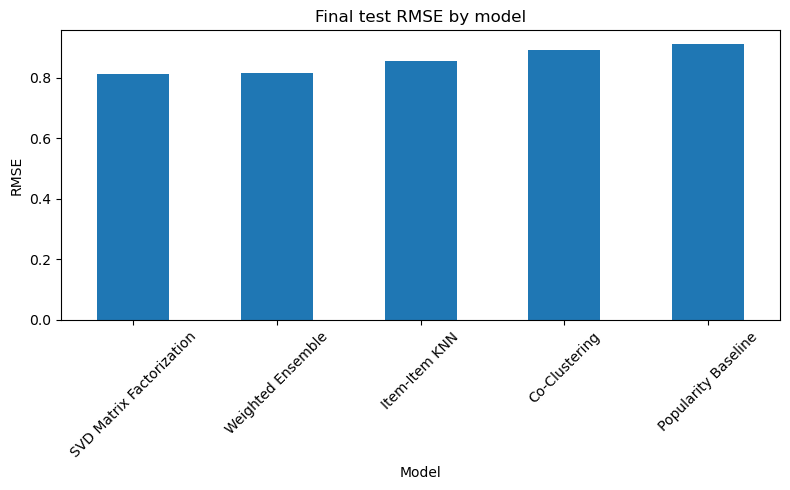

In [42]:
# Visualize the final RMSE comparison.
# Lower RMSE means better predictive accuracy on the held-out test interactions.
fig, ax = plt.subplots(figsize=(8, 5))
phase3_rmse_results_df.sort_values("test_rmse", ascending=True).plot(
    x="model",
    y="test_rmse",
    kind="bar",
    legend=False,
    ax=ax,
)
ax.set_title("Final test RMSE by model")
ax.set_xlabel("Model")
ax.set_ylabel("RMSE")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "phase3_test_rmse_comparison.png", dpi=150)
plt.show()

### Observation for report

The RMSE table shows that SVD has the best final predictive accuracy on the held-out test set, with a test RMSE of about 0.8113. The weighted ensemble follows closely with a test RMSE of about 0.8142. Item-item KNN, Co-Clustering, and the popularity baseline perform worse by RMSE.

This supports the Phase 2 model-selection decision: SVD was already the strongest model on the validation set, and it remains strongest on the final test set. However, RMSE only evaluates prediction error on the transformed rating-like score. It does not fully measure whether a model places relevant songs near the top of a recommendation list. Therefore, I still evaluate ranking metrics and ROC/AUC after RMSE.

## 3.3 Ranking metrics: Precision@K, Recall@K, and F1@K

Ranking metrics evaluate whether relevant songs appear near the top of the model's ranked list.

In this notebook, I calculate ranking metrics on the held-out test interactions. For each user, I rank that user's test interactions by predicted score. Interactions with `liked = 1` are treated as relevant because they represent repeated listens.

This is an offline ranking approximation. It does not rank every unobserved song in the full catalogue, because that would be much more expensive for KNN and Co-Clustering. Instead, it checks whether the model ranks known repeated-listen test interactions above weaker one-play test interactions.

In [43]:
def precision_recall_f1_at_k(prediction_df, score_col, k=10, relevant_col="liked"):
    """
    Calculate user-averaged Precision@K, Recall@K, and F1@K.

    The function ranks each user's held-out test interactions by a model score.
    Interactions with liked=1 are treated as relevant.

    Users without any relevant test interactions are skipped because recall is
    undefined when there are no positive interactions to recover.
    """
    user_metrics = []

    # Check that the required columns exist before calculating metrics.
    # This makes errors easier to understand if the prediction table changes.
    required_columns = {"user_id", score_col, relevant_col}
    missing_columns = required_columns - set(prediction_df.columns)

    if missing_columns:
        raise KeyError(f"Missing required columns for ranking metrics: {missing_columns}")

    for user_id, user_df in prediction_df.groupby("user_id"):
        # Count how many relevant held-out interactions this user has.
        n_relevant = user_df[relevant_col].sum()

        # Skip users with no repeated-listen positives in the test set.
        # These users do not provide recall information.
        if n_relevant == 0:
            continue

        # Rank the user's held-out test interactions by the selected model score.
        ranked_user_df = user_df.sort_values(score_col, ascending=False)

        # Keep the top K rows, or all rows if the user has fewer than K test interactions.
        top_k = ranked_user_df.head(k)
        effective_k = len(top_k)

        # Count how many relevant interactions appear in the top K.
        hits_at_k = top_k[relevant_col].sum()

        # Precision measures how many top-K recommendations are relevant.
        precision = hits_at_k / effective_k if effective_k > 0 else 0

        # Recall measures how many relevant test interactions are recovered.
        recall = hits_at_k / n_relevant if n_relevant > 0 else 0

        # F1 combines precision and recall into one harmonic-mean score.
        f1 = (
            2 * precision * recall / (precision + recall)
            if (precision + recall) > 0
            else 0
        )

        user_metrics.append({
            "user_id": user_id,
            "precision_at_k": precision,
            "recall_at_k": recall,
            "f1_at_k": f1,
            "n_test_interactions": len(user_df),
            "n_relevant": n_relevant,
        })

    user_metrics_df = pd.DataFrame(user_metrics)

    # Return NaN values if no users have relevant test interactions.
    # This should not happen here, but it makes the function robust.
    if user_metrics_df.empty:
        return {
            "precision_at_k": np.nan,
            "recall_at_k": np.nan,
            "f1_at_k": np.nan,
            "evaluated_users": 0,
        }

    return {
        "precision_at_k": user_metrics_df["precision_at_k"].mean(),
        "recall_at_k": user_metrics_df["recall_at_k"].mean(),
        "f1_at_k": user_metrics_df["f1_at_k"].mean(),
        "evaluated_users": len(user_metrics_df),
    }

In [44]:
# Calculate ranking metrics for K=10 and K=30.
# K=10 matches the Top 10 playlist examples, while K=30 gives a broader ranking view.
ranking_results = []

for k in [10, 30]:
    for model_name, pred_col in model_prediction_columns.items():
        # Calculate user-averaged Precision@K, Recall@K, and F1@K for one model.
        metrics = precision_recall_f1_at_k(
            phase3_test_prediction_df,
            score_col=pred_col,
            k=k,
            relevant_col="liked",
        )

        # Store the model name, prediction column, K value, and calculated metrics.
        ranking_results.append({
            "model": model_name,
            "prediction_column": pred_col,
            "k": k,
            **metrics,
        })

# Keep one combined dataframe for later merging into the final evaluation table.
phase3_ranking_results_df = pd.DataFrame(ranking_results)

# Create a separate K=10 table.
# Sorting by F1@K is useful because F1 balances precision and recall.
phase3_ranking_k10_df = (
    phase3_ranking_results_df[phase3_ranking_results_df["k"] == 10]
    .sort_values(["f1_at_k", "recall_at_k", "precision_at_k"], ascending=[False, False, False])
    .reset_index(drop=True)
)

# Create a separate K=30 table.
# K=30 is broader, but it can be less discriminative if most held-out positives already fit into the top 30.
phase3_ranking_k30_df = (
    phase3_ranking_results_df[phase3_ranking_results_df["k"] == 30]
    .sort_values(["f1_at_k", "recall_at_k", "precision_at_k"], ascending=[False, False, False])
    .reset_index(drop=True)
)

print("Ranking metrics at K=10:")
display(phase3_ranking_k10_df)

print("Ranking metrics at K=30:")
display(phase3_ranking_k30_df)

# Save ranking metrics for the technical report.
phase3_ranking_results_df.to_csv(
    OUTPUTS_DIR / "phase3_ranking_metrics.csv",
    index=False,
)

phase3_ranking_k10_df.to_csv(
    OUTPUTS_DIR / "phase3_ranking_metrics_k10.csv",
    index=False,
)

phase3_ranking_k30_df.to_csv(
    OUTPUTS_DIR / "phase3_ranking_metrics_k30.csv",
    index=False,
)

Ranking metrics at K=10:


,model,prediction_column,k,precision_at_k,recall_at_k,f1_at_k,evaluated_users
0,Weighted Ensemble,ensemble_pred,10,0.535763,0.953467,0.646321,1819
1,Item-Item KNN,item_knn_pred,10,0.535378,0.953702,0.646039,1819
2,SVD Matrix Factorization,svd_pred,10,0.534223,0.950701,0.644516,1819
3,Co-Clustering,coclustering_pred,10,0.533674,0.950081,0.644028,1819
4,Popularity Baseline,popularity_pred,10,0.533674,0.951491,0.644017,1819


Ranking metrics at K=30:


,model,prediction_column,k,precision_at_k,recall_at_k,f1_at_k,evaluated_users
0,Co-Clustering,coclustering_pred,30,0.529018,0.998759,0.652555,1819
1,Item-Item KNN,item_knn_pred,30,0.528944,0.998624,0.652462,1819
2,Weighted Ensemble,ensemble_pred,30,0.528908,0.998489,0.652397,1819
3,SVD Matrix Factorization,svd_pred,30,0.528889,0.998503,0.652390,1819
4,Popularity Baseline,popularity_pred,30,0.528853,0.998253,0.652300,1819


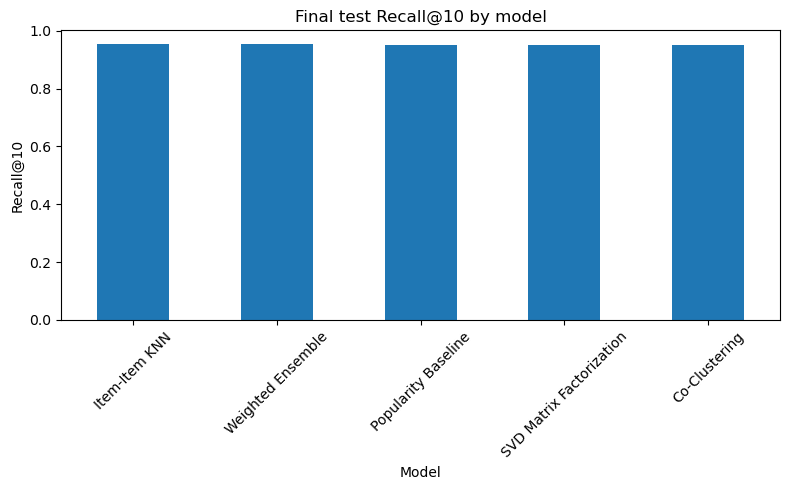

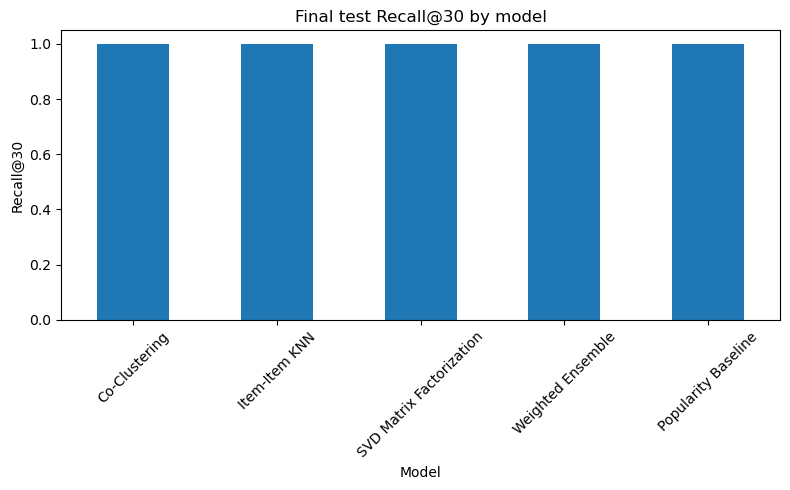

In [45]:
# Visualize Recall@K because the brief explicitly mentions improving recall.
# Higher Recall@K means the model recovers more repeated-listen test interactions near the top.
for k in [10, 30]:
    plot_df = phase3_ranking_results_df[
        phase3_ranking_results_df["k"] == k
    ].sort_values("recall_at_k", ascending=False)

    fig, ax = plt.subplots(figsize=(8, 5))
    plot_df.plot(
        x="model",
        y="recall_at_k",
        kind="bar",
        legend=False,
        ax=ax,
    )
    ax.set_title(f"Final test Recall@{k} by model")
    ax.set_xlabel("Model")
    ax.set_ylabel(f"Recall@{k}")
    ax.tick_params(axis="x", rotation=45)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f"phase3_recall_at_{k}_comparison.png", dpi=150)
    plt.show()

### Observation for report

The ranking metrics evaluate a different aspect of recommendation quality than RMSE. RMSE measures how close the predicted score is to the transformed rating-like value, while Precision@K, Recall@K, and F1@K measure whether repeated-listen interactions appear near the top of each user's ranked test interactions.

At K=10, Item-Item KNN achieves the highest Recall@10, while the weighted ensemble achieves the highest F1@10. This means KNN recovers the largest share of repeated-listen interactions in the Top 10, while the ensemble gives the best balance between precision and recall at K=10.

At K=30, recall is extremely high for all models, close to 1.0. This makes K=30 less useful for distinguishing between models in this offline setup. The likely reason is that the evaluation ranks each user's held-out test interactions rather than the full unseen song catalogue, so a Top 30 list often covers most of the user's test interactions.

This ranking evaluation is therefore a practical offline approximation. It is useful for comparing model ranking behaviour, but it should not be interpreted as a full production-scale top-N evaluation over every unseen song.

## 3.4 Classification metrics: ROC curves and AUC

The binary `liked` label from Phase 1 allows the model scores to be evaluated as classifiers. A positive interaction means that the user listened to the song at least twice.

ROC curves show the trade-off between true positive rate and false positive rate across possible score thresholds. AUC summarizes this curve into one value. A higher AUC means the model is better at assigning higher scores to repeated-listen interactions than to one-play interactions.

In [46]:
# Calculate ROC curves and AUC values for all models.
# The continuous model predictions are treated as scores for the binary liked label.
roc_results = []
roc_curve_data = {}

y_true = phase3_test_prediction_df["liked"]

for model_name, pred_col in model_prediction_columns.items():
    y_score = phase3_test_prediction_df[pred_col]

    # Calculate false positive rate, true positive rate, and score thresholds.
    fpr, tpr, thresholds = roc_curve(y_true, y_score)

    # AUC summarizes the ROC curve into a single discrimination score.
    auc_score = auc(fpr, tpr)

    roc_results.append({
        "model": model_name,
        "prediction_column": pred_col,
        "auc": auc_score,
    })

    roc_curve_data[model_name] = {
        "fpr": fpr,
        "tpr": tpr,
        "thresholds": thresholds,
    }

phase3_auc_results_df = (
    pd.DataFrame(roc_results)
    .sort_values("auc", ascending=False)
    .reset_index(drop=True)
)

display(phase3_auc_results_df)

# Save AUC results for the technical report.
phase3_auc_results_df.to_csv(
    OUTPUTS_DIR / "phase3_auc_results.csv",
    index=False,
)

,model,prediction_column,auc
0,SVD Matrix Factorization,svd_pred,0.717333
1,Weighted Ensemble,ensemble_pred,0.714683
2,Item-Item KNN,item_knn_pred,0.683315
3,Co-Clustering,coclustering_pred,0.683231
4,Popularity Baseline,popularity_pred,0.593397


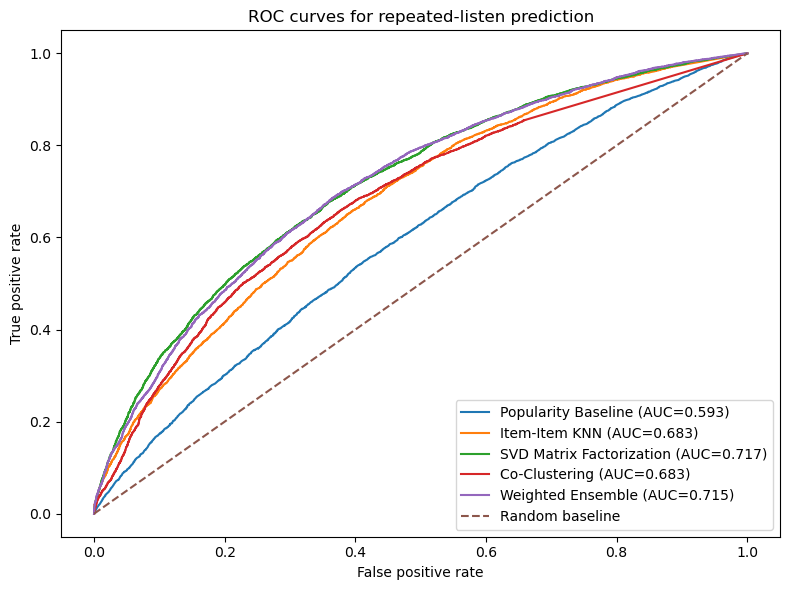

In [47]:
# Plot ROC curves for all models on one figure.
# The diagonal reference line represents random ranking performance.
fig, ax = plt.subplots(figsize=(8, 6))

for model_name, curve in roc_curve_data.items():
    auc_score = phase3_auc_results_df.loc[
        phase3_auc_results_df["model"] == model_name,
        "auc",
    ].iloc[0]

    ax.plot(
        curve["fpr"],
        curve["tpr"],
        label=f"{model_name} (AUC={auc_score:.3f})",
    )

ax.plot([0, 1], [0, 1], linestyle="--", label="Random baseline")
ax.set_title("ROC curves for repeated-listen prediction")
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "phase3_roc_curves.png", dpi=150)
plt.show()

### Observation for report

ROC/AUC evaluates whether model scores separate repeated-listen interactions from one-play interactions. This is different from RMSE because it ignores the exact size of the rating error and focuses on whether positive interactions receive higher scores than negative interactions.

SVD achieves the highest AUC at about 0.7173, followed closely by the weighted ensemble at about 0.7147. This supports the RMSE result: SVD is not only the best rating-prediction model, but also the best model for separating repeated-listen positives from one-play interactions.

The popularity baseline has the lowest AUC at about 0.5934. This shows that popularity alone is not strong at distinguishing whether a specific user will repeatedly listen to a specific song, even though it remains useful as a simple baseline and cold-start fallback.

## 3.5 Combined evaluation summary

The final evaluation table combines RMSE, AUC, and ranking metrics. This makes it easier to compare whether the same model is best across all metrics or whether different models are better for different evaluation goals.

In [48]:
# Create compact ranking summaries for K=10 and K=30.
# These are merged into one final model-comparison table.
ranking_k10 = (
    phase3_ranking_results_df[phase3_ranking_results_df["k"] == 10]
    [["model", "precision_at_k", "recall_at_k", "f1_at_k"]]
    .rename(columns={
        "precision_at_k": "precision_at_10",
        "recall_at_k": "recall_at_10",
        "f1_at_k": "f1_at_10",
    })
)

ranking_k30 = (
    phase3_ranking_results_df[phase3_ranking_results_df["k"] == 30]
    [["model", "precision_at_k", "recall_at_k", "f1_at_k"]]
    .rename(columns={
        "precision_at_k": "precision_at_30",
        "recall_at_k": "recall_at_30",
        "f1_at_k": "f1_at_30",
    })
)

# Combine all Phase 3 metrics into one summary table.
phase3_final_evaluation_df = (
    phase3_rmse_results_df
    .merge(phase3_auc_results_df[["model", "auc"]], on="model", how="left")
    .merge(ranking_k10, on="model", how="left")
    .merge(ranking_k30, on="model", how="left")
    .sort_values("test_rmse")
    .reset_index(drop=True)
)

display(phase3_final_evaluation_df)

# Save the complete final evaluation table for the technical report.
phase3_final_evaluation_df.to_csv(
    OUTPUTS_DIR / "phase3_final_evaluation_summary.csv",
    index=False,
)

,model,prediction_column,test_rmse,auc,precision_at_10,recall_at_10,f1_at_10,precision_at_30,recall_at_30,f1_at_30
0,SVD Matrix Factorization,svd_pred,0.811285,0.717333,0.534223,0.950701,0.644516,0.528889,0.998503,0.652390
1,Weighted Ensemble,ensemble_pred,0.814174,0.714683,0.535763,0.953467,0.646321,0.528908,0.998489,0.652397
2,Item-Item KNN,item_knn_pred,0.856205,0.683315,0.535378,0.953702,0.646039,0.528944,0.998624,0.652462
3,Co-Clustering,coclustering_pred,0.889757,0.683231,0.533674,0.950081,0.644028,0.529018,0.998759,0.652555
4,Popularity Baseline,popularity_pred,0.910262,0.593397,0.533674,0.951491,0.644017,0.528853,0.998253,0.652300


In [49]:
# Print the best-performing model by each major evaluation perspective.
# This helps make the final interpretation explicit and avoids relying on only one metric.
best_rmse_model = phase3_final_evaluation_df.sort_values("test_rmse").iloc[0]
best_auc_model = phase3_final_evaluation_df.sort_values("auc", ascending=False).iloc[0]
best_recall10_model = phase3_final_evaluation_df.sort_values("recall_at_10", ascending=False).iloc[0]
best_f1_10_model = phase3_final_evaluation_df.sort_values("f1_at_10", ascending=False).iloc[0]

print("Best model by RMSE:", best_rmse_model["model"], "| RMSE:", round(best_rmse_model["test_rmse"], 4))
print("Best model by AUC:", best_auc_model["model"], "| AUC:", round(best_auc_model["auc"], 4))
print("Best model by Recall@10:", best_recall10_model["model"], "| Recall@10:", round(best_recall10_model["recall_at_10"], 4))
print("Best model by F1@10:", best_f1_10_model["model"], "| F1@10:", round(best_f1_10_model["f1_at_10"], 4))

Best model by RMSE: SVD Matrix Factorization | RMSE: 0.8113
Best model by AUC: SVD Matrix Factorization | AUC: 0.7173
Best model by Recall@10: Item-Item KNN | Recall@10: 0.9537
Best model by F1@10: Weighted Ensemble | F1@10: 0.6463


### Observation for report

The combined evaluation table shows that no single metric tells the full story.

SVD is the strongest model for predictive accuracy and classification performance. It has the best test RMSE at about 0.8113 and the highest AUC at about 0.7173. This makes SVD the strongest overall model when the goal is accurate score prediction and repeated-listen discrimination.

The weighted ensemble does not beat SVD on RMSE or AUC, but it does achieve the best F1@10. This means the ensemble is still valuable as an advanced strategy because it gives the best balance between Precision@10 and Recall@10.

Item-Item KNN has the best Recall@10, but only by a very small margin. This suggests that the neighbourhood-based model is strong at recovering repeated-listen interactions in short recommendation lists, even though it is worse than SVD by RMSE and AUC.

Because the metrics favour slightly different models, I should not rely on one score only. Based on the full table, SVD is the safest final personalized recommendation model, while the weighted ensemble remains a useful alternative when the priority is balanced Top 10 ranking performance.

## 3.6 Conclusion (Phase 3)

Phase 3 evaluates the models using the required metric groups from the project brief:

- **Predictive accuracy:** RMSE on the held-out test set.
- **Ranking metrics:** Precision@10, Recall@10, F1@10, Precision@30, Recall@30, and F1@30.
- **Classification metrics:** ROC curves and AUC for the repeated-listen `liked` label.

This gives a broader evaluation than RMSE alone. RMSE shows how well the models predict the transformed rating-like score. Ranking metrics show whether repeated-listen interactions appear near the top of the ranked list. ROC/AUC shows whether the models separate repeated listens from one-play interactions across different score thresholds.

The final results show that SVD is the strongest model for predictive accuracy and classification performance. It has the lowest test RMSE and the highest AUC. This supports the earlier Phase 2 decision to treat SVD as the selected personalized recommendation model.

The weighted ensemble remains useful as the required advanced strategy. It does not beat SVD on RMSE or AUC, but it achieves the best F1@10, meaning it gives the strongest balance between Precision@10 and Recall@10 in the Top 10 ranking evaluation.

Item-Item KNN achieves the highest Recall@10, although the difference is small. This shows that the memory-based neighbourhood model is competitive for recovering repeated-listen interactions near the top of the ranked test interactions, even though it performs worse than SVD on RMSE and AUC.

K=30 is less useful for model selection in this evaluation because all models achieve very high Recall@30. This is likely caused by the offline setup, where each user's held-out test interactions are ranked instead of scoring the full unseen song catalogue. For this reason, K=10 is the more meaningful ranking setting for the Top 10 playlist objective.

Overall, SVD is the safest final personalized recommendation model. The popularity baseline remains the cold-start strategy for new users, and the weighted-average ensemble remains a defensible advanced strategy that could be further improved in future work.

---

# Phase 4 - Solution Design & Strategy

The previous phases focused on data preparation, model development, and quantitative evaluation. This phase translates those results into an implementation strategy.

The project brief asks for three practical design decisions:

1. **Latency vs. accuracy:** compare model inference speed and decide which models are suitable for real-time recommendations or batch processing.
2. **Deployment strategy:** propose how the recommendation system should be used in practice.
3. **Cold-start strategy:** define how the system handles a user with zero listening history.

This phase is intentionally lighter than the previous phases. The notebook provides reproducible evidence and concise design notes, while the technical report contains the polished business-facing explanation.


## 4.1 Latency vs. accuracy

Accuracy is not the only deployment concern. A model that performs well but is slow at inference may be better suited for offline batch recommendation generation, while a faster model may be more useful for real-time scenarios.

To keep the notebook efficient, I estimate inference speed on a reproducible sample of held-out test interactions. This does not represent full production infrastructure, but it gives a practical comparison of relative inference cost across the models.


In [50]:
# Create a reproducible sample for inference-speed testing.
# Timing the full catalogue for every user would be expensive and is not necessary for a light Phase 4 comparison.
LATENCY_SAMPLE_SIZE = 1000
LATENCY_REPEATS = 3

phase4_latency_sample_df = test_df.sample(
    n=min(LATENCY_SAMPLE_SIZE, len(test_df)),
    random_state=RANDOM_STATE,
).copy()

# Surprise expects a list of (user_id, song_id, rating) tuples for test-time prediction.
# I use the same sampled rows for every model so the timing comparison remains fair.
phase4_latency_testset = list(
    phase4_latency_sample_df[["user_id", "song_id", "rating"]]
    .itertuples(index=False, name=None)
)

print("Latency sample interactions:", len(phase4_latency_sample_df))
print("Timing repeats per model:", LATENCY_REPEATS)


Latency sample interactions: 1000
Timing repeats per model: 3


In [51]:
def time_prediction_function(model_name, prediction_function, n_interactions, n_repeats=3):
    """
    Time a prediction function over several repeats.

    The returned values are practical inference-speed estimates:
    - average total seconds for the sampled batch,
    - average milliseconds per interaction,
    - approximate interactions per second.

    This is a notebook-level benchmark, not a production load test.
    """
    durations = []

    for repeat_idx in range(n_repeats):
        # Use a high-resolution timer so small prediction-time differences are measurable.
        start_time = time.perf_counter()

        # Run the prediction function once.
        # The output is intentionally not displayed because only timing is needed here.
        _ = prediction_function()

        end_time = time.perf_counter()
        durations.append(end_time - start_time)

    avg_seconds = np.mean(durations)
    std_seconds = np.std(durations)

    return {
        "model": model_name,
        "sample_interactions": n_interactions,
        "repeats": n_repeats,
        "avg_inference_seconds": avg_seconds,
        "std_inference_seconds": std_seconds,
        "avg_ms_per_interaction": (avg_seconds / n_interactions) * 1000,
        "interactions_per_second": n_interactions / avg_seconds if avg_seconds > 0 else np.nan,
    }

In [52]:
def predict_popularity_latency_sample():
    """Predict the sampled interactions with the popularity baseline."""
    return popularity_model.predict_many(phase4_latency_sample_df)

In [53]:
def predict_item_knn_latency_sample():
    """Predict the sampled interactions with the fitted item-item KNN model."""
    return item_knn.test(phase4_latency_testset)

In [54]:
def predict_svd_latency_sample():
    """Predict the sampled interactions with the fitted SVD model."""
    return svd_model.test(phase4_latency_testset)

In [55]:
def predict_coclustering_latency_sample():
    """Predict the sampled interactions with the fitted Co-Clustering model."""
    return coclustering_model.test(phase4_latency_testset)

In [56]:
def predict_weighted_ensemble_latency_sample():
    """
    Predict the sampled interactions with the weighted ensemble.

    This represents online ensemble inference, where all component model predictions
    must be calculated before applying the weighted average. In a production system,
    ensemble recommendations could also be precomputed offline to reduce serving latency.
    """
    popularity_scores = popularity_model.predict_many(phase4_latency_sample_df)

    item_knn_scores = np.array([
        prediction.est for prediction in item_knn.test(phase4_latency_testset)
    ])

    svd_scores = np.array([
        prediction.est for prediction in svd_model.test(phase4_latency_testset)
    ])

    coclustering_scores = np.array([
        prediction.est for prediction in coclustering_model.test(phase4_latency_testset)
    ])

    ensemble_scores = (
        ensemble_weights["popularity_pred"] * popularity_scores
        + ensemble_weights["item_knn_pred"] * item_knn_scores
        + ensemble_weights["svd_pred"] * svd_scores
        + ensemble_weights["coclustering_pred"] * coclustering_scores
    )

    return np.clip(ensemble_scores, 1, 5)

In [57]:
# Time inference for every model on the same sampled test interactions.
# This compares practical prediction speed, not training time.
latency_results = [
    time_prediction_function(
        "Popularity Baseline",
        predict_popularity_latency_sample,
        n_interactions=len(phase4_latency_sample_df),
        n_repeats=LATENCY_REPEATS,
    ),
    time_prediction_function(
        "Item-Item KNN",
        predict_item_knn_latency_sample,
        n_interactions=len(phase4_latency_sample_df),
        n_repeats=LATENCY_REPEATS,
    ),
    time_prediction_function(
        "SVD Matrix Factorization",
        predict_svd_latency_sample,
        n_interactions=len(phase4_latency_sample_df),
        n_repeats=LATENCY_REPEATS,
    ),
    time_prediction_function(
        "Co-Clustering",
        predict_coclustering_latency_sample,
        n_interactions=len(phase4_latency_sample_df),
        n_repeats=LATENCY_REPEATS,
    ),
    time_prediction_function(
        "Weighted Ensemble",
        predict_weighted_ensemble_latency_sample,
        n_interactions=len(phase4_latency_sample_df),
        n_repeats=LATENCY_REPEATS,
    ),
]

phase4_latency_results_df = (
    pd.DataFrame(latency_results)
    .sort_values("avg_ms_per_interaction", ascending=True)
    .reset_index(drop=True)
)

display(phase4_latency_results_df)

# Save the latency results for the technical report.
phase4_latency_results_df.to_csv(
    OUTPUTS_DIR / "phase4_latency_results.csv",
    index=False,
)

,model,sample_interactions,repeats,avg_inference_seconds,std_inference_seconds,avg_ms_per_interaction,interactions_per_second
0,Popularity Baseline,1000,3,0.001018,0.000362,0.001018,981900.272922
1,Co-Clustering,1000,3,0.006207,0.001027,0.006207,161104.099097
2,SVD Matrix Factorization,1000,3,0.013751,0.000967,0.013751,72721.279490
3,Item-Item KNN,1000,3,0.080599,0.005393,0.080599,12407.153141
4,Weighted Ensemble,1000,3,0.115924,0.007750,0.115924,8626.309161


In [58]:
# Combine final evaluation quality metrics with inference-speed estimates.
# This makes the accuracy-latency trade-off visible in one report-ready table.
phase4_accuracy_latency_df = phase3_final_evaluation_df.merge(
    phase4_latency_results_df[
        ["model", "avg_ms_per_interaction", "interactions_per_second"]
    ],
    on="model",
    how="left",
)

# Select the most relevant columns for solution-design discussion.
phase4_accuracy_latency_df = phase4_accuracy_latency_df[
    [
        "model",
        "test_rmse",
        "auc",
        "precision_at_10",
        "recall_at_10",
        "f1_at_10",
        "avg_ms_per_interaction",
        "interactions_per_second",
    ]
].sort_values("test_rmse", ascending=True)

display(phase4_accuracy_latency_df)

# Save the combined accuracy-latency table for the technical report.
phase4_accuracy_latency_df.to_csv(
    OUTPUTS_DIR / "phase4_accuracy_latency_tradeoff.csv",
    index=False,
)


,model,test_rmse,auc,precision_at_10,recall_at_10,f1_at_10,avg_ms_per_interaction,interactions_per_second
0,SVD Matrix Factorization,0.811285,0.717333,0.534223,0.950701,0.644516,0.013751,72721.279490
1,Weighted Ensemble,0.814174,0.714683,0.535763,0.953467,0.646321,0.115924,8626.309161
2,Item-Item KNN,0.856205,0.683315,0.535378,0.953702,0.646039,0.080599,12407.153141
3,Co-Clustering,0.889757,0.683231,0.533674,0.950081,0.644028,0.006207,161104.099097
4,Popularity Baseline,0.910262,0.593397,0.533674,0.951491,0.644017,0.001018,981900.272922


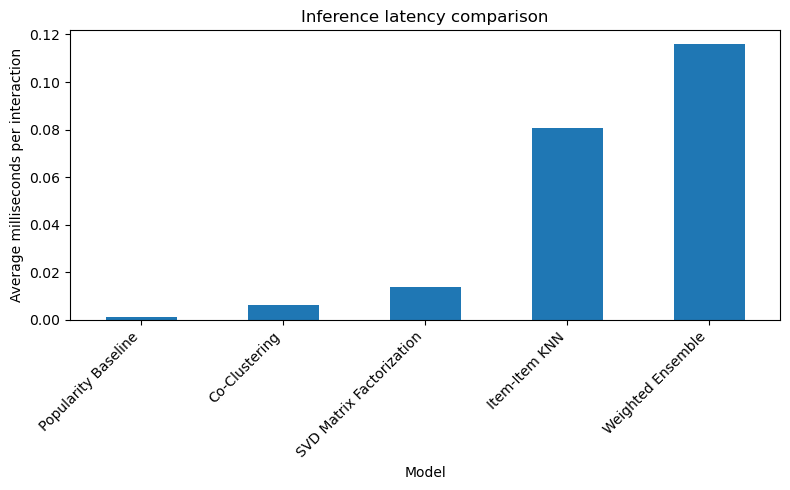

In [59]:
# Visualize inference speed as milliseconds per interaction.
# Lower values mean faster prediction and are therefore better for real-time serving.
fig, ax = plt.subplots(figsize=(8, 5))
phase4_latency_results_df.sort_values("avg_ms_per_interaction").plot(
    x="model",
    y="avg_ms_per_interaction",
    kind="bar",
    legend=False,
    ax=ax,
)

ax.set_title("Inference latency comparison")
ax.set_xlabel("Model")
ax.set_ylabel("Average milliseconds per interaction")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "phase4_inference_latency_comparison.png", dpi=150)
plt.show()


### Observation for report

The latency comparison adds an implementation perspective to the Phase 3 accuracy results. The popularity baseline is the fastest model in the timing sample because it only uses item-level popularity statistics. However, it also has the weakest RMSE and AUC, so it is best used as a cold-start fallback rather than as the main personalized model.

SVD gives the best overall accuracy result, with the lowest test RMSE and highest AUC, while also remaining very fast at inference time. This makes SVD the strongest default personalized recommendation model for real-time or cached serving.

Item-Item KNN and the weighted ensemble are slower in the timing comparison. KNN depends on neighbourhood-style similarity behaviour, and the ensemble must calculate several component predictions before combining them. The ensemble is therefore more suitable for offline or batch-generated recommendation lists, especially when balanced Top 10 ranking quality is more important than latency.

Co-Clustering is also fast in this timing sample, but it is weaker than SVD on RMSE and AUC. I therefore treat it mainly as an analytical or segmentation-oriented model rather than the default serving model.

## 4.2 Deployment strategy

The final system should not rely on one model for every situation. Different recommendation contexts have different requirements. A homepage request needs fast responses, while a daily playlist can be generated offline with more expensive models.

The deployment strategy below translates the model results into practical system roles.


In [60]:
# Define a practical deployment role for each model.
# This table connects the modelling results to implementation utility.
phase4_deployment_strategy_df = pd.DataFrame([
    {
        "scenario": "New user with zero listening history",
        "recommended_model": "Popularity Baseline",
        "serving_mode": "Real-time",
        "reason": "No user history is available, so collaborative models cannot personalize yet.",
    },
    {
        "scenario": "Default personalized recommendations",
        "recommended_model": "SVD Matrix Factorization",
        "serving_mode": "Real-time or cached batch",
        "reason": "SVD has the strongest RMSE/AUC performance and efficient prediction behaviour.",
    },
    {
        "scenario": "Discovery-oriented Top 10 playlist",
        "recommended_model": "Weighted Ensemble",
        "serving_mode": "Batch precomputation",
        "reason": "The ensemble has strong balanced Top 10 ranking performance, but online scoring is more expensive.",
    },
    {
        "scenario": "Recall-focused candidate recovery",
        "recommended_model": "Item-Item KNN",
        "serving_mode": "Batch or candidate-generation support",
        "reason": "KNN achieved strong Recall@10, making it useful for recovering relevant candidates.",
    },
    {
        "scenario": "Exploratory segmentation or catalogue analysis",
        "recommended_model": "Co-Clustering",
        "serving_mode": "Offline analysis",
        "reason": "Co-Clustering gives useful user-song group structure, but it is not the strongest final serving model.",
    },
])

display(phase4_deployment_strategy_df)

# Save the deployment strategy table for the technical report.
phase4_deployment_strategy_df.to_csv(
    OUTPUTS_DIR / "phase4_deployment_strategy.csv",
    index=False,
)


,scenario,recommended_model,serving_mode,reason
0,New user with zero listening history,Popularity Baseline,Real-time,"No user history is available, so collaborative..."
1,Default personalized recommendations,SVD Matrix Factorization,Real-time or cached batch,SVD has the strongest RMSE/AUC performance and...
2,Discovery-oriented Top 10 playlist,Weighted Ensemble,Batch precomputation,The ensemble has strong balanced Top 10 rankin...
3,Recall-focused candidate recovery,Item-Item KNN,Batch or candidate-generation support,"KNN achieved strong Recall@10, making it usefu..."
4,Exploratory segmentation or catalogue analysis,Co-Clustering,Offline analysis,Co-Clustering gives useful user-song group str...


### Observation for report

The recommended deployment plan is a hybrid strategy. SVD should be the default personalized recommender because it performed best on RMSE and AUC while remaining suitable for efficient inference. This makes it appropriate for compute-optimized recommendation scenarios.

The weighted ensemble should not replace SVD as the default online model, because it requires multiple model predictions per score. However, it is still valuable for batch-generated playlists or discovery-oriented contexts, especially because it performed strongly on balanced Top 10 ranking quality.

The popularity baseline should be deployed as the cold-start fallback. It is simple, fast, and does not require user history, which makes it suitable for brand-new users.


## 4.3 Cold-start strategy

A user with zero listening history cannot receive collaborative-filtering recommendations, because there are no user-song interactions from which to infer personal taste. For that situation, the system needs a separate cold-start flow.

In this project, the cold-start strategy is the popularity baseline from Phase 2. This is a practical first recommendation list because it uses item-level listening behaviour from the whole user base rather than personal history.


In [61]:
# Build a cold-start Top 10 list directly from the fitted popularity baseline.
# This avoids relying on older helper functions from earlier notebook versions.
# The popularity baseline is appropriate here because a new user has no listening history yet.

phase4_cold_start_top10 = (
    popularity_model.item_stats_
    .reset_index()
    .sort_values("popularity_rank_score", ascending=False)
    .head(10)
    .copy()
)

# Add readable metadata so the cold-start recommendation list can be interpreted in the report.
# The metadata table was cleaned in Phase 1 and gives readable song titles, artists, releases, and years.
phase4_cold_start_top10 = phase4_cold_start_top10.merge(
    songs_clean[["song_id", "title", "artist_name", "release", "year"]],
    on="song_id",
    how="left",
)

# Fill rare missing display values defensively.
# This should not change the recommendation logic, because ranking is still based on popularity_rank_score.
phase4_cold_start_top10["title"] = phase4_cold_start_top10["title"].fillna("Unknown title")
phase4_cold_start_top10["artist_name"] = phase4_cold_start_top10["artist_name"].fillna("Unknown artist")
phase4_cold_start_top10["release"] = phase4_cold_start_top10["release"].fillna("Unknown release")
phase4_cold_start_top10["year"] = phase4_cold_start_top10["year"].fillna(0).astype(int)

# Display the cold-start recommendation list.
# This simulates the first recommendation list for a user with zero listening history.
print("Cold-start Top 10 recommendation list:")
display(
    phase4_cold_start_top10[
        [
            "song_id",
            "title",
            "artist_name",
            "release",
            "year",
            "n_users",
            "total_plays",
            "popularity_rank_score",
        ]
    ]
)

# Save the cold-start recommendation list for the technical report.
phase4_cold_start_top10.to_csv(
    OUTPUTS_DIR / "phase4_cold_start_top10.csv",
    index=False,
)

Cold-start Top 10 recommendation list:


,song_id,title,artist_name,release,year,n_users,total_plays,popularity_rank_score
0,SOBONKR12A58A7A7E0,You're The One,Dwight Yoakam,If There Was A Way,1990,206,2369,3.297958
1,SOAUWYT12A81C206F1,Undo,Björk,Vespertine Live,2001,252,1850,3.103190
2,SOSXLTC12AF72A7F54,Revelry,Kings Of Leon,Only By The Night,2008,235,1864,3.015751
3,SORJICW12A8C13640D,Mercy:The Laundromat,Pavement,Westing (By Musket and Sextant),1993,68,567,2.919639
4,SOEGIYH12A6D4FC0E3,Horn Concerto No. 4 in E flat K495: II. Romanc...,Barry Tuckwell/Academy of St Martin-in-the-Fie...,Mozart - Eine kleine Nachtmusik,0,175,1214,2.905860
5,SOUFTBI12AB0183F65,Invalid,Tub Ring,Fermi Paradox,2002,118,918,2.866850
6,SOAXGDH12A8C13F8A1,Dog Days Are Over (Radio Edit),Florence + The Machine,Now That's What I Call Music! 75,0,306,1353,2.806427
7,SOFRQTD12A81C233C0,Sehr kosmisch,Harmonia,Musik von Harmonia,0,315,1306,2.780714
8,SOBOUPA12A6D4F81F1,Sincerité Et Jalousie,Alliance Ethnik,Simple Et Funky,0,106,658,2.779462
9,SOVIZNF12AF72A710A,The Big Gundown,The Prodigy,Invaders Must Die Remixes and Bonus Tracks,2009,23,266,2.778980


### Observation for report

For a new user with zero listening history, the system should initially recommend popular songs. This is not personalized yet, but it is reliable because it does not require user-specific interaction data. This directly addresses the new-user cold-start problem.

Once the user starts listening, the system can move through a staged personalization strategy:

1. **Zero interactions:** use the popularity baseline.
2. **A few interactions:** blend popularity with simple item-based similarity.
3. **Enough listening history:** switch to SVD as the default personalized model.
4. **Batch discovery playlists:** use the weighted ensemble when the goal is balanced Top 10 discovery rather than lowest latency.

This staged strategy is defensible because collaborative filtering models need user interaction history before they can personalize effectively. It also matches the broader recommender-system idea that cold-start users require a fallback strategy until enough behavioural evidence has been collected.

## 4.4 Conclusion (Phase 4)

Phase 4 translates the modelling and evaluation results into an implementation strategy.

The main recommendation is to use **SVD Matrix Factorization** as the default personalized recommendation model. It is the strongest overall model from the evaluation phase because it has the best predictive accuracy and classification performance, while also being suitable for efficient inference.

The **Popularity Baseline** should be used for users with zero listening history. It is fast, simple, and does not require personal interaction data, making it the correct cold-start fallback.

The **Weighted Ensemble** should be used selectively, especially for batch-generated discovery playlists. It is valuable because it combines popularity, item-item similarity, latent factors, and co-clustering structure, but it is more expensive for real-time scoring because all component predictions need to be calculated.

The final deployment strategy is therefore:

- **Cold start:** Popularity Baseline.
- **Default personalized recommendations:** SVD Matrix Factorization.
- **Batch discovery playlists:** Weighted Ensemble.
- **Candidate recovery / recall support:** Item-Item KNN.
- **Offline segmentation insight:** Co-Clustering.

This design balances accuracy, ranking quality, latency, and practical deployment utility.
